# Équation de Nagumo 2D — Comparaison de schémas numériques

$$u_t = D\,(u_{xx}+u_{yy}) + u(1-u)(u-a)$$

| | Schéma | Type |
|---|---|---|
| **RK4** | Runge-Kutta 4 | Explicite |
| **EI** | Euler Implicite | Semi-implicite |
| **ADI** | Peaceman-Rachford | Semi-implicite (résolutions 1D) |
| **AB2** | Adams-Bashforth 2 | Explicite multi-pas |
| **AM2** | IMEX Crank-Nicolson | Semi-implicite |

**Conditions aux limites :** Neumann homogènes (flux nul) sur tout le bord.

---


In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from IPython.display import display, HTML, Video
import warnings, time, os

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print("✅ Imports OK")

# Création du dossier img s'il n'existe pas
if not os.path.exists('img'):
    os.makedirs('img')
    print("📁 Dossier 'img' créé")


✅ Imports OK


## 1. Construction des opérateurs discrets

In [2]:
def build_laplacian_1D(N, ds, D):
    """Laplacien 1D tridiagonal avec CL Neumann par points fantômes."""
    e    = np.ones(N + 1)
    diag = np.full(N + 1, -2.0)
    A    = sp.diags([e[:-1], diag, e[:-1]], [-1, 0, 1], format='lil')
    # Bord gauche : u_{-1} = u_1  →  double le coeff de u_1
    A[0, 1]   = 2.0
    # Bord droit  : u_{N+1} = u_{N-1}  →  double le coeff de u_{N-1}
    A[-1, -2] = 2.0
    return (D / ds**2) * A.tocsr()


def build_system(params):
    """Construit toutes les matrices et variables utiles."""
    Lx, Ly = params['Lx'], params['Ly']
    D, a   = params['D'],  params['a']
    Nx, Ny = params['Nx'], params['Ny']

    dx, dy = Lx / Nx, Ly / Ny
    x = np.linspace(0, Lx, Nx + 1)
    y = np.linspace(0, Ly, Ny + 1)
    X, Y = np.meshgrid(x, y)          # shape (Ny+1, Nx+1)
    Ntot = (Nx + 1) * (Ny + 1)

    Ax = build_laplacian_1D(Nx, dx, D)
    Ay = build_laplacian_1D(Ny, dy, D)

    Ix  = sp.eye(Nx + 1, format='csr')
    Iy  = sp.eye(Ny + 1, format='csr')
    I2D = sp.eye(Ntot,   format='csr')
    A2D = sp.kron(Iy, Ax, format='csr') + sp.kron(Ay, Ix, format='csr')

    f   = lambda u: u * (1 - u) * (u - a)
    G   = lambda uv: A2D @ uv + f(uv)

    h        = min(dx, dy)
    mu_exp   = 0.12
    dt_exp   = mu_exp * h**2 / D
    Nt_exp   = int(np.ceil(params['T'] / dt_exp))
    dt_exp   = params['T'] / Nt_exp

    dt_imp   = 10 * dt_exp
    Nt_imp   = int(np.ceil(params['T'] / dt_imp))
    dt_imp   = params['T'] / Nt_imp

    return dict(
        x=x, y=y, X=X, Y=Y, Nx=Nx, Ny=Ny, Ntot=Ntot,
        dx=dx, dy=dy, h=h,
        Ax=Ax, Ay=Ay, Ix=Ix, Iy=Iy, I2D=I2D, A2D=A2D,
        f=f, G=G,
        dt_exp=dt_exp, Nt_exp=Nt_exp,
        dt_imp=dt_imp, Nt_imp=Nt_imp,
        D=D, a=a, T=params['T'],
    )


def make_initial_condition(X, Y, Lx, Ly, ic_type='front_plan'):
    """Condition initiale au choix."""
    if ic_type == 'front_plan':
        x0, sigma = Lx / 2, 2.0
        return 1.0 / (1.0 + np.exp((X - x0) / sigma))

    elif ic_type == 'onde_circulaire':
        R0 = 15.0
        r  = np.sqrt((X - Lx/2)**2 + (Y - Ly/2)**2)
        return (r < R0).astype(float)

    elif ic_type == 'front_perturbe':
        x0, sigma = Lx / 2, 2.0
        eps       = 5.0
        return 1.0 / (1.0 + np.exp((X - x0 - eps * np.sin(2*np.pi*Y/Ly)) / sigma))

    else:
        raise ValueError(f"ic_type inconnu : {ic_type}")


def track_front(u_mid, x, dx):
    """Position de l'isovaleur u = 0.5 sur un profil 1D."""
    idx = np.where((u_mid[:-1] >= 0.5) & (u_mid[1:] < 0.5))[0]
    if idx.size:
        i = idx[0]
        return x[i] + dx * (0.5 - u_mid[i]) / (u_mid[i+1] - u_mid[i])
    return np.nan

print("✅ Fonctions utilitaires définies")


✅ Fonctions utilitaires définies


## 2. Paramètres physiques — réglage interactif

In [ ]:
# ── Widgets de paramètres ────────────────────────────────────────────────────
style = {'description_width': '160px'}
layout_w = widgets.Layout(width='460px')

w_D  = widgets.FloatSlider(value=1.0, min=0.1, max=5.0,  step=0.1,
                            description='Diffusion D :', style=style, layout=layout_w)
w_a  = widgets.FloatSlider(value=0.25, min=0.01, max=0.49, step=0.01,
                            description='Seuil a :', style=style, layout=layout_w,
                            readout_format='.2f')
w_T  = widgets.FloatSlider(value=20.0, min=2.0, max=60.0, step=1.0,
                            description='Temps final T :', style=style, layout=layout_w)
w_Lx = widgets.FloatSlider(value=60.0, min=20.0, max=120.0, step=10.0,
                            description='Lx = Ly :', style=style, layout=layout_w)
w_Nx = widgets.IntSlider(value=80, min=20, max=140, step=10,
                          description='Nx = Ny :', style=style, layout=layout_w)
w_ic = widgets.Dropdown(
    options=[('Front plan vertical', 'front_plan'),
             ('Onde circulaire',     'onde_circulaire'),
             ('Front plan perturbé', 'front_perturbe')],
    value='front_plan', description='Condition initiale :', style=style,
    layout=layout_w)

# Boîte d'informations mise à jour dynamiquement
info_out = widgets.Output()

def update_info(*args):
    info_out.clear_output(wait=True)
    h  = min(w_Lx.value / w_Nx.value, w_Lx.value / w_Nx.value)
    dt = 0.12 * h**2 / w_D.value
    Nt = int(np.ceil(w_T.value / dt))
    c  = np.sqrt(2 * w_D.value) * (0.5 - w_a.value)
    with info_out:
        print(f"  h = {h:.4f}  |  dt_exp ≈ {dt:.5f}  |  Nt_exp ≈ {Nt:,}  |  c* ≈ {c:.4f}")

for w in [w_D, w_a, w_T, w_Lx, w_Nx]:
    w.observe(update_info, names='value')

title_box = widgets.HTML("<b style='font-size:13px'>📐 Paramètres de simulation</b>")
display(widgets.VBox([title_box, w_D, w_a, w_T, w_Lx, w_Nx, w_ic, info_out]))
update_info()


## 3. Lancement de la simulation

In [4]:
# ── Dictionnaire global pour stocker les résultats ───────────────────────────
RESULTS = {}

def run_simulation(params, ic_type, snap_every=5, verbose=True):
    """Lance tous les schémas et stocke des snapshots réguliers."""
    sys = build_system(params)
    x, y, X, Y = sys['x'], sys['y'], sys['X'], sys['Y']
    Nx, Ny = sys['Nx'], sys['Ny']
    Lx, Ly = params['Lx'], params['Ly']
    dx, dy = sys['dx'], sys['dy']
    A2D, Ax, Ay = sys['A2D'], sys['Ax'], sys['Ay']
    f, G = sys['f'], sys['G']
    I2D = sys['I2D']
    Ix, Iy = sys['Ix'], sys['Iy']
    dt_exp, Nt_exp = sys['dt_exp'], sys['Nt_exp']
    dt_imp, Nt_imp = sys['dt_imp'], sys['Nt_imp']
    T = params['T']

    U0     = make_initial_condition(X, Y, Lx, Ly, ic_type)
    j_mid  = Ny // 2

    c_th   = np.sqrt(2 * params['D']) * (0.5 - params['a'])

    def v2m(v): return v.reshape(Ny + 1, Nx + 1)

    # ── Aide : enregistre un snapshot ─────────────────────────────────────
    def record(snaps, fronts, u_mat, t_val):
        snaps.append((t_val, u_mat.copy()))
        fronts.append((t_val, track_front(u_mat[j_mid, :], x, dx)))

    results = {}
    bar_style = 'width:100%;height:12px;border-radius:6px;background:#4CAF50'

    # ══════════════════════════════════════════════════════════════════════
    # RK4 — Runge-Kutta 4
    # ══════════════════════════════════════════════════════════════════════
    if verbose: print("⏳ RK4  ...", end='', flush=True); t0 = time.time()
    u = U0.flatten().copy()
    snaps, fronts = [], []
    record(snaps, fronts, v2m(u), 0.0)
    for n in range(Nt_exp):
        K1 = G(u)
        K2 = G(u + 0.5 * dt_exp * K1)
        K3 = G(u + 0.5 * dt_exp * K2)
        K4 = G(u + dt_exp * K3)
        u += (dt_exp / 6) * (K1 + 2*K2 + 2*K3 + K4)
        if (n + 1) % snap_every == 0 or n == Nt_exp - 1:
            record(snaps, fronts, v2m(u), (n + 1) * dt_exp)
    results['RK4'] = {'snaps': snaps, 'fronts': fronts, 'dt': dt_exp, 'Nt': Nt_exp}
    if verbose: print(f"  ✓ {time.time()-t0:.1f}s")

    # ══════════════════════════════════════════════════════════════════════
    # Euler Implicite (EI)
    # ══════════════════════════════════════════════════════════════════════
    if verbose: print("⏳ Euler Implicite ...", end='', flush=True); t0 = time.time()
    M_EI = I2D - dt_imp * A2D
    lu_EI = spla.splu(M_EI.tocsc())
    u = U0.flatten().copy()
    snaps, fronts = [], []
    record(snaps, fronts, v2m(u), 0.0)
    for n in range(Nt_imp):
        rhs = u + dt_imp * f(u)
        u   = lu_EI.solve(rhs)
        record(snaps, fronts, v2m(u), (n + 1) * dt_imp)
    results['EI'] = {'snaps': snaps, 'fronts': fronts, 'dt': dt_imp, 'Nt': Nt_imp}
    if verbose: print(f"  ✓ {time.time()-t0:.1f}s")

    # ══════════════════════════════════════════════════════════════════════
    # ADI Peaceman-Rachford
    # ══════════════════════════════════════════════════════════════════════
    if verbose: print("⏳ ADI  ...", end='', flush=True); t0 = time.time()
    alpha  = dt_imp / 2
    Mx_adi = Ix  - alpha * Ax
    My_adi = Iy  - alpha * Ay
    lu_x   = spla.splu(Mx_adi.tocsc())
    lu_y   = spla.splu(My_adi.tocsc())
    U_adi  = U0.copy()
    snaps, fronts = [], []
    record(snaps, fronts, U_adi, 0.0)
    for n in range(Nt_imp):
        Ay_U   = Ay @ U_adi          # (Ny+1) x (Nx+1)
        Uhalf  = np.zeros_like(U_adi)
        for j in range(Ny + 1):
            rhs_j      = U_adi[j, :] + alpha * Ay_U[j, :] + dt_imp * f(U_adi[j, :])
            Uhalf[j,:] = lu_x.solve(rhs_j)
        Ax_Uh  = Uhalf @ Ax.T        # (Ny+1) x (Nx+1)  (Ax symétrique)
        U_new  = np.zeros_like(Uhalf)
        for i in range(Nx + 1):
            rhs_i     = Uhalf[:, i] + alpha * Ax_Uh[:, i]
            U_new[:,i] = lu_y.solve(rhs_i)
        U_adi = U_new
        record(snaps, fronts, U_adi, (n + 1) * dt_imp)
    results['ADI'] = {'snaps': snaps, 'fronts': fronts, 'dt': dt_imp, 'Nt': Nt_imp}
    if verbose: print(f"  ✓ {time.time()-t0:.1f}s")

    # ══════════════════════════════════════════════════════════════════════
    # Adams-Bashforth 2 (AB2)
    # ══════════════════════════════════════════════════════════════════════
    if verbose: print("⏳ AB2  ...", end='', flush=True); t0 = time.time()
    u = U0.flatten().copy()
    G_old = G(u)
    u    += dt_exp * G_old          # 1er pas : Euler explicite
    G_new = G(u)
    snaps, fronts = [], []
    record(snaps, fronts, v2m(U0.flatten()), 0.0)
    record(snaps, fronts, v2m(u), dt_exp)
    for n in range(1, Nt_exp):
        u    += dt_exp * (1.5 * G_new - 0.5 * G_old)
        G_old = G_new
        G_new = G(u)
        if (n + 1) % snap_every == 0 or n == Nt_exp - 1:
            record(snaps, fronts, v2m(u), (n + 1) * dt_exp)
    results['AB2'] = {'snaps': snaps, 'fronts': fronts, 'dt': dt_exp, 'Nt': Nt_exp}
    if verbose: print(f"  ✓ {time.time()-t0:.1f}s")

    # ══════════════════════════════════════════════════════════════════════
    # AM2 — IMEX Crank-Nicolson
    # ══════════════════════════════════════════════════════════════════════
    if verbose: print("⏳ AM2  ...", end='', flush=True); t0 = time.time()
    M_AM2 = I2D - (dt_imp / 2) * A2D
    lu_AM2 = spla.splu(M_AM2.tocsc())
    u = U0.flatten().copy()
    snaps, fronts = [], []
    record(snaps, fronts, v2m(u), 0.0)
    for n in range(Nt_imp):
        rhs = u + (dt_imp / 2) * (A2D @ u) + dt_imp * f(u)
        u   = lu_AM2.solve(rhs)
        record(snaps, fronts, v2m(u), (n + 1) * dt_imp)
    results['AM2'] = {'snaps': snaps, 'fronts': fronts, 'dt': dt_imp, 'Nt': Nt_imp}
    if verbose: print(f"  ✓ {time.time()-t0:.1f}s")

    return results, sys, U0, c_th


# ── Bouton de lancement ───────────────────────────────────────────────────────
btn_run  = widgets.Button(description='▶  Lancer la simulation',
                          button_style='success',
                          layout=widgets.Layout(width='260px', height='40px'))
prog_out = widgets.Output()

def on_run_clicked(b):
    global RESULTS
    prog_out.clear_output(wait=True)
    with prog_out:
        params = dict(
            D=w_D.value, a=w_a.value, T=w_T.value,
            Lx=w_Lx.value, Ly=w_Lx.value,
            Nx=w_Nx.value, Ny=w_Nx.value,
        )
        print(f"Paramètres : D={params['D']}, a={params['a']}, T={params['T']}, "
              f"Nx={params['Nx']}, C.I.={w_ic.value}")
        RESULTS['data'], RESULTS['sys'], RESULTS['U0'], RESULTS['c_th'] = \
            run_simulation(params, w_ic.value, snap_every=4, verbose=True)
        RESULTS['params'] = params
        print(f"\n🎯 Vitesse théorique c* = {RESULTS['c_th']:.4f}")
        print("✅ Simulation terminée ! Rendez-vous aux cellules suivantes.")

btn_run.on_click(on_run_clicked)
display(btn_run, prog_out)


Button(button_style='success', description='▶  Lancer la simulation', layout=Layout(height='40px', width='260p…

Output()

## 4. Visualisation interactive avec slider temporel

In [18]:
def make_interactive_viewer():
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation (cellule précédente).")
        return

    data    = RESULTS['data']
    sys_    = RESULTS['sys']
    X, Y    = sys_['X'], sys_['Y']
    x       = sys_['x']
    c_th    = RESULTS['c_th']
    params  = RESULTS['params']

    COLORS  = {'RK4': '#1f77b4', 'EI': '#d62728', 'ADI': '#17becf',
                'AB2': '#2ca02c', 'AM2': '#9467bd'}
    LABELS  = {'RK4': 'RK4', 'EI': 'Euler Impl.', 'ADI': 'ADI P-R',
                'AB2': 'AB2', 'AM2': 'AM2 (IMEX CN)'}

    # Listes des instants disponibles (union des instants RK4 — le plus dense)
    t_vals = [s[0] for s in data['RK4']['snaps']]
    n_snaps = len(t_vals)

    # ── Widgets ──────────────────────────────────────────────────────────
    sl_time = widgets.IntSlider(
        value=0, min=0, max=n_snaps - 1, step=1,
        description='Instant n°',
        style={'description_width': '100px'},
        layout=widgets.Layout(width='700px'),
        continuous_update=True,
    )
    dd_scheme = widgets.Dropdown(
        options=list(LABELS.items()),
        value='RK4',
        description='Schéma affiché :',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='320px'),
    )
    chk_contour = widgets.Checkbox(value=True, description='Afficher isovaleur 0.5')
    chk_profile = widgets.Checkbox(value=True, description='Profil central y=Ly/2')

    play_btn = widgets.Play(
        value=0, min=0, max=n_snaps - 1, step=1,
        interval=120, description='▶ Lecture',
        layout=widgets.Layout(width='200px'),
    )
    widgets.jslink((play_btn, 'value'), (sl_time, 'value'))

    out_fig = widgets.Output()
    
    # ── Initialisation de la figure ──────────────────────────────────────
    with out_fig:
        plt.ioff()  # Empêche l'affichage automatique
        ncols = 2 # On prépare toujours 2 colonnes pour éviter de recréer la figure
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        plt.ion()
        
    ax_heat = axes[0]
    ax_prof = axes[1]
    
    # Objets persistants pour la mise à jour
    plot_objs = {
        'im': None,
        'contour': None,
        'lines': {},
        'cbar': None
    }

    def nearest_snap(scheme, t_target):
        s :naps = data[scheme]['snaps']
        ts    = [s[0] for s in snaps]
        idx   = int(np.argmin(np.abs(np.array(ts) - t_target)))
        return snaps[idx]

    def update(change=None):
        t_target = t_vals[sl_time.value]
        scheme   = dd_scheme.value
        t_snap, U = nearest_snap(scheme, t_target)

        # 1. Mise à jour Heatmap
        if plot_objs['im'] is None:
            plot_objs['im'] = ax_heat.pcolormesh(X, Y, U, cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
            plot_objs['cbar'] = fig.colorbar(plot_objs['im'], ax=ax_heat, label='u')
            ax_heat.set_xlabel('x'); ax_heat.set_ylabel('y')
            ax_heat.set_aspect('equal')
        else:
            plot_objs['im'].set_array(U.ravel())
        
        ax_heat.set_title(f'{LABELS[scheme]}   —   t = {t_snap:.2f}', fontsize=12)

        # 2. Mise à jour Contour
        if plot_objs['contour']:
            for coll in plot_objs['contour'].collections:
                coll.remove()
        
        if chk_contour.value:
            plot_objs['contour'] = ax_heat.contour(X, Y, U, levels=[0.5], colors='k', linewidths=1.5)
        else:
            plot_objs['contour'] = None

        # 3. Mise à jour Profil
        ax_prof.set_visible(chk_profile.value)
        if chk_profile.value:
            j_mid = sys_['Ny'] // 2
            for sc in data:
                t2, U2 = nearest_snap(sc, t_target) # Use t_target to be consistent
                if sc not in plot_objs['lines']:
                    line, = ax_prof.plot(x, U2[j_mid, :], color=COLORS[sc],
                                       label=LABELS[sc], linewidth=1.6)
                    plot_objs['lines'][sc] = line
                else:
                    plot_objs['lines'][sc].set_ydata(U2[j_mid, :])
            
            if 'h_line' not in plot_objs:
                plot_objs['h_line'] = ax_prof.axhline(0.5, color='k', ls='--', lw=0.8)
                ax_prof.set_ylim(-0.05, 1.05)
                ax_prof.set_xlabel('x');  ax_prof.set_ylabel('u(x, Ly/2, t)')
                ax_prof.legend(fontsize=8, loc='upper right')
                ax_prof.grid(True, alpha=0.3)
            
            ax_prof.set_title(f'Profil central   t ≈ {t_snap:.2f}', fontsize=12)
        
        plt.tight_layout()
        fig.canvas.draw_idle()

    for w in [sl_time, dd_scheme, chk_contour, chk_profile]:
        w.observe(update, names='value')

    title = widgets.HTML("<b style='font-size:14px'>🎛️ Explorateur temporel</b>")
    row1  = widgets.HBox([play_btn, sl_time])
    row2  = widgets.HBox([dd_scheme, chk_contour, chk_profile])
    ui    = widgets.VBox([title, row1, row2, out_fig])
    display(ui)
    update()   # premier affichage


make_interactive_viewer()


## 5. Comparaison multi-schémas à un instant donné

In [19]:
def make_comparison_viewer():
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    sys_   = RESULTS['sys']
    X, Y   = sys_['X'], sys_['Y']
    T      = RESULTS['params']['T']

    sl_t = widgets.FloatSlider(
        value=T, min=0.0, max=T, step=T / 50,
        description='Temps t :',
        style={'description_width': '90px'},
        layout=widgets.Layout(width='650px'),
        readout_format='.2f',
    )
    out2 = widgets.Output()

    def update_cmp(change=None):
        t_target = sl_t.value
        with out2:
            out2.clear_output(wait=True)
            schemes = list(data.keys())
            fig, axes = plt.subplots(2, 3, figsize=(15, 9))
            axes = axes.flatten()
            for k, sc in enumerate(schemes):
                snaps = data[sc]['snaps']
                ts    = np.array([s[0] for s in snaps])
                idx   = int(np.argmin(np.abs(ts - t_target)))
                t_r, U = snaps[idx]
                ax = axes[k]
                im = ax.pcolormesh(X, Y, U, cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
                ax.contour(X, Y, U, levels=[0.5], colors='k', linewidths=1.2)
                plt.colorbar(im, ax=ax)
                ax.set_title(f'{sc}   t = {t_r:.2f}', fontsize=11)
                ax.set_xlabel('x'); ax.set_ylabel('y')
                ax.set_aspect('equal')
            # Cacher la 6e case (on n'a que 5 schémas)
            axes[5].axis('off')
            plt.suptitle(f'Comparaison des schémas — t ≈ {t_target:.2f}', fontsize=13)
            plt.tight_layout()
            plt.savefig(f'img/comparaison_schemas_t_{t_target:.2f}.png', dpi=150, bbox_inches='tight')
            plt.show()

    sl_t.observe(update_cmp, names='value')
    display(widgets.VBox([sl_t, out2]))
    update_cmp()

make_comparison_viewer()


## 6. Suivi du front et comparaison avec la vitesse théorique

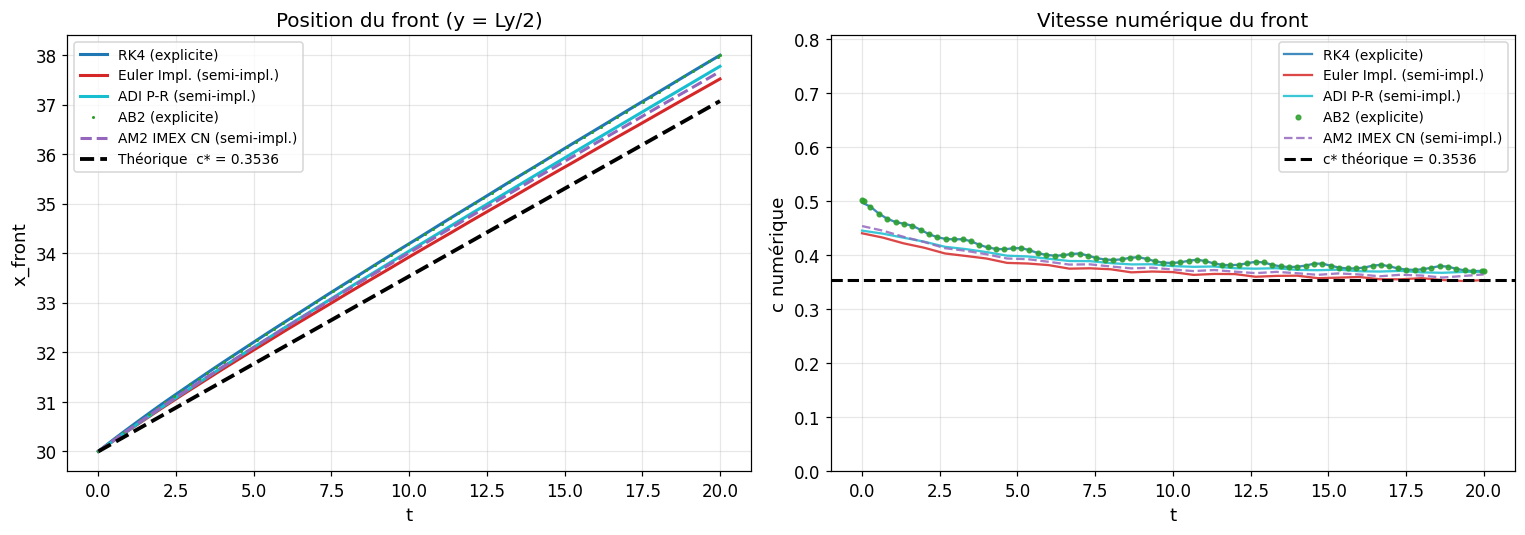

c* théorique = √(2D)·(½−a) = √(2.00) × 0.25 = 0.3536


In [20]:
def plot_front_tracking():
    if 'data' not in RESULTS:
        print("Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    c_th   = RESULTS['c_th']
    T      = RESULTS['params']['T']
    Lx     = RESULTS['params']['Lx']

    COLORS = {'RK4': '#1f77b4', 'EI': '#d62728', 'ADI': '#17becf',
               'AB2': '#2ca02c', 'AM2': '#9467bd'}
    STYLES = {'RK4': '-',  'EI': '-',  'ADI': '-', 'AB2': '.', 'AM2': '--'}
    LABELS = {'RK4': 'RK4 (explicite)',
               'EI':  'Euler Impl. (semi-impl.)',
               'ADI': 'ADI P-R (semi-impl.)',
               'AB2': 'AB2 (explicite)',
               'AM2': 'AM2 IMEX CN (semi-impl.)'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Position du front ────────────────────────────────────────────────
    ax = axes[0]
    for sc in data:
        fronts = data[sc]['fronts']
        ts  = np.array([f[0] for f in fronts])
        xfs = np.array([f[1] for f in fronts])
        ax.plot(ts, xfs, STYLES[sc], color=COLORS[sc],
                label=LABELS[sc], linewidth=2, markersize=2)
    t_th = np.linspace(0, T, 200)
    ax.plot(t_th, Lx/2 + c_th * t_th, 'k--', linewidth=2.5,
            label=f'Théorique  c* = {c_th:.4f}')
    ax.set_xlabel('t', fontsize=12); ax.set_ylabel('x_front', fontsize=12)
    ax.set_title('Position du front (y = Ly/2)', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # ── Estimation de la vitesse numérique ──────────────────────────────
    ax2 = axes[1]
    for sc in data:
        fronts = data[sc]['fronts']
        ts  = np.array([f[0] for f in fronts])
        xfs = np.array([f[1] for f in fronts])
        # Vitesse par différences finies
        valid = ~np.isnan(xfs)
        if valid.sum() > 5:
            v_num = np.gradient(xfs[valid], ts[valid])
            ax2.plot(ts[valid], v_num, STYLES[sc], color=COLORS[sc],
                     label=LABELS[sc], linewidth=1.5, alpha=0.85)
    ax2.axhline(c_th, color='k', ls='--', lw=2,
                label=f'c* théorique = {c_th:.4f}')
    ax2.set_ylim(0, 2 * c_th + 0.1)
    ax2.set_xlabel('t', fontsize=12); ax2.set_ylabel('c numérique', fontsize=12)
    ax2.set_title('Vitesse numérique du front', fontsize=13)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('img/front_tracking.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"c* théorique = √(2D)·(½−a) = √({2*RESULTS['params']['D']:.2f}) × {0.5-RESULTS['params']['a']:.2f} = {c_th:.4f}")

plot_front_tracking()


## 7. Surface 3D du profil final

In [21]:
def plot_3d_surface():
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    sys_   = RESULTS['sys']
    X, Y   = sys_['X'], sys_['Y']
    T      = RESULTS['params']['T']

    LABELS = {'RK4': 'RK4', 'EI': 'Euler Impl.', 'ADI': 'ADI P-R',
               'AB2': 'AB2', 'AM2': 'AM2 (IMEX CN)'}

    sl_sc = widgets.Dropdown(
        options=list(LABELS.items()), value='RK4',
        description='Schéma :', style={'description_width': '90px'},
        layout=widgets.Layout(width='280px'),
    )
    out3d = widgets.Output()

    def update_3d(change=None):
        sc     = sl_sc.value
        snaps  = data[sc]['snaps']
        t_f, U = snaps[-1]
        with out3d:
            out3d.clear_output(wait=True)
            fig = plt.figure(figsize=(9, 6))
            ax  = fig.add_subplot(111, projection='3d')
            surf = ax.plot_surface(X, Y, U, cmap='jet', edgecolor='none', alpha=0.9)
            fig.colorbar(surf, ax=ax, shrink=0.5, label='u')
            ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
            ax.set_zlim(0, 1)
            ax.set_title(f'Profil final — {LABELS[sc]}   t = {t_f:.2f}', fontsize=12)
            ax.view_init(elev=30, azim=45)
            plt.tight_layout()
            plt.savefig(f'img/surface_3d_{sc}.png', dpi=150, bbox_inches='tight')
            plt.show()

    sl_sc.observe(update_3d, names='value')
    display(widgets.VBox([sl_sc, out3d]))
    update_3d()

from mpl_toolkits.mplot3d import Axes3D   # noqa
plot_3d_surface()


## 8. Génération de la vidéo animée

In [22]:
def generate_video(scheme='RK4', fps=15, output_path='img/nagumo_animation.mp4',
                   show_profile=True):
    """Génère une vidéo .mp4 de l'évolution temporelle."""
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    sys_   = RESULTS['sys']
    X, Y   = sys_['X'], sys_['Y']
    x      = sys_['x']
    c_th   = RESULTS['c_th']
    T      = RESULTS['params']['T']
    Lx     = RESULTS['params']['Lx']
    j_mid  = sys_['Ny'] // 2

    snaps  = data[scheme]['snaps']
    LABELS = {'RK4': 'RK4', 'EI': 'Euler Implicite', 'ADI': 'ADI Peaceman-Rachford',
               'AB2': 'Adams-Bashforth 2', 'AM2': 'AM2 IMEX Crank-Nicolson'}
    COLORS = {'RK4': '#1f77b4', 'EI': '#d62728', 'ADI': '#17becf',
               'AB2': '#2ca02c', 'AM2': '#9467bd'}

    ncols = 2 if show_profile else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5.5))
    if ncols == 1: axes = [axes]

    # ── Frame initiale ──────────────────────────────────────────────────
    t0, U0_snap = snaps[0]
    im = axes[0].pcolormesh(X, Y, U0_snap, cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
    ctr_list = [axes[0].contour(X, Y, U0_snap, levels=[0.5], colors='k', linewidths=1.5)]
    plt.colorbar(im, ax=axes[0], label='u')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
    axes[0].set_aspect('equal')
    title_ax = axes[0].set_title('')

    line_num, line_th = None, None
    if show_profile:
        axes[1].set_xlim(0, Lx); axes[1].set_ylim(-0.05, 1.05)
        axes[1].set_xlabel('x'); axes[1].set_ylabel('u(x, Ly/2, t)')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(0.5, color='k', ls='--', lw=0.8, label='u = 0.5')
        line_num, = axes[1].plot([], [], color=COLORS[scheme], lw=2,
                                  label=LABELS[scheme])
        line_th,  = axes[1].plot([], [], 'k-', lw=1.5, alpha=0.4,
                                  label=f'c* = {c_th:.4f}')
        axes[1].legend(fontsize=9)
        title_ax2 = axes[1].set_title('')

    plt.tight_layout()

    def animate(frame):
        t_f, U = snaps[frame]
        im.set_array(U.ravel())

        # Retirer l'ancien contour
        for coll in ctr_list[0].collections:
            coll.remove()
        ctr_list[0] = axes[0].contour(X, Y, U, levels=[0.5], colors='k', linewidths=1.5)
        title_ax.set_text(f'{LABELS[scheme]}   —   t = {t_f:.2f} / {T:.1f}')

        if show_profile:
            line_num.set_data(x, U[j_mid, :])
            x_front_th = Lx / 2 + c_th * t_f
            line_th.set_data([x_front_th, x_front_th], [0, 1])
            title_ax2.set_text(f'Profil y = Ly/2   t = {t_f:.2f}')
        return [im]

    print(f"🎬 Création de la vidéo : {len(snaps)} frames  —  schéma {scheme} ...")
    ani = animation.FuncAnimation(fig, animate, frames=len(snaps),
                                   interval=1000 // fps, blit=False)
    writer = animation.FFMpegWriter(fps=fps, bitrate=1800,
                                     extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
    ani.save(output_path, writer=writer, dpi=130)
    plt.close(fig)
    print(f"✅ Vidéo sauvegardée : {output_path}")
    return output_path


# ── Widgets pour la vidéo ─────────────────────────────────────────────────────
LABELS_VID = {'RK4': 'RK4', 'EI': 'Euler Implicite', 'ADI': 'ADI P-R',
               'AB2': 'AB2', 'AM2': 'AM2 IMEX CN'}

dd_vid  = widgets.Dropdown(
    options=list(LABELS_VID.items()), value='RK4',
    description='Schéma vidéo :', style={'description_width': '130px'},
    layout=widgets.Layout(width='340px'),
)
sl_fps  = widgets.IntSlider(value=15, min=5, max=30, step=1,
                             description='FPS :',
                             style={'description_width': '60px'},
                             layout=widgets.Layout(width='300px'))
chk_prof_vid = widgets.Checkbox(value=True, description='+ profil 1D')
btn_vid = widgets.Button(description='🎬 Générer la vidéo',
                          button_style='info',
                          layout=widgets.Layout(width='240px', height='38px'))
out_vid = widgets.Output()

def on_vid_clicked(b):
    with out_vid:
        out_vid.clear_output(wait=True)
        path = generate_video(
            scheme=dd_vid.value,
            fps=sl_fps.value,
            show_profile=chk_prof_vid.value,
        )
        if path and os.path.exists(path):
            from IPython.display import Video
            display(Video(path, embed=True, width=700))

btn_vid.on_click(on_vid_clicked)
display(widgets.VBox([
    widgets.HTML("<b>Paramètres de la vidéo</b>"),
    widgets.HBox([dd_vid, sl_fps, chk_prof_vid]),
    btn_vid,
    out_vid,
]))


## 9. Vidéo comparaison 4-en-1 (tous schémas simultanément)

In [23]:
def generate_comparison_video(fps=12, output_path='img/nagumo_comparison.mp4'):
    """Vidéo avec les 4 schémas principaux côte à côte."""
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    sys_   = RESULTS['sys']
    X, Y   = sys_['X'], sys_['Y']
    T      = RESULTS['params']['T']

    SCHEMES = ['RK4', 'EI', 'ADI', 'AB2', 'AM2']
    LABELS  = {'RK4': 'RK4', 'EI': 'Euler Impl.', 'ADI': 'ADI P-R',
                'AB2': 'AB2', 'AM2': 'AM2 (IMEX CN)'}

    # On se base sur les instants du schéma le plus court (implicite)
    t_ref   = np.array([s[0] for s in data['EI']['snaps']])
    n_frames = len(t_ref)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    ims, ctrs = [], []
    for k, sc in enumerate(SCHEMES):
        t0, U0s = data[sc]['snaps'][0]
        im = axes[k].pcolormesh(X, Y, U0s, cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
        plt.colorbar(im, ax=axes[k])
        ctrs.append([axes[k].contour(X, Y, U0s, levels=[0.5], colors='k', linewidths=1.2)])
        axes[k].set_aspect('equal')
        axes[k].set_xlabel('x'); axes[k].set_ylabel('y')
        ims.append(im)
    axes[5].axis('off')

    sup = plt.suptitle('', fontsize=13)
    plt.tight_layout()

    def animate(frame):
        t_target = t_ref[frame]
        sup.set_text(f'Nagumo 2D — t = {t_target:.2f} / {T:.1f}')
        for k, sc in enumerate(SCHEMES):
            snaps = data[sc]['snaps']
            ts    = np.array([s[0] for s in snaps])
            idx   = int(np.argmin(np.abs(ts - t_target)))
            _, U  = snaps[idx]
            ims[k].set_array(U.ravel())
            for coll in ctrs[k][0].collections:
                coll.remove()
            ctrs[k][0] = axes[k].contour(X, Y, U, levels=[0.5], colors='k', linewidths=1.2)
            axes[k].set_title(f'{LABELS[sc]}  t={t_target:.1f}', fontsize=10)
        return ims

    print(f"🎬 Vidéo comparaison : {n_frames} frames ...")
    ani = animation.FuncAnimation(fig, animate, frames=n_frames,
                                   interval=1000 // fps, blit=False)
    writer = animation.FFMpegWriter(fps=fps, bitrate=2200,
                                     extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
    ani.save(output_path, writer=writer, dpi=110)
    plt.close(fig)
    print(f"✅ Vidéo comparaison : {output_path}")
    return output_path


btn_cmp_vid = widgets.Button(description='🎬 Vidéo 5-en-1 (tous schémas)',
                              button_style='warning',
                              layout=widgets.Layout(width='320px', height='38px'))
sl_fps2  = widgets.IntSlider(value=10, min=4, max=24, step=1,
                              description='FPS :', style={'description_width': '50px'},
                              layout=widgets.Layout(width='260px'))
out_cmp_vid = widgets.Output()

def on_cmp_vid(b):
    with out_cmp_vid:
        out_cmp_vid.clear_output(wait=True)
        path = generate_comparison_video(fps=sl_fps2.value)
        if path and os.path.exists(path):
            display(Video(path, embed=True, width=800))

btn_cmp_vid.on_click(on_cmp_vid)
display(widgets.HBox([btn_cmp_vid, sl_fps2]), out_cmp_vid)


Output()

## 10. Tableau récapitulatif

In [9]:
def print_summary():
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data    = RESULTS['data']
    c_th    = RESULTS['c_th']
    params  = RESULTS['params']
    sys_    = RESULTS['sys']

    print("=" * 70)
    print(f"  PARAMÈTRES : D={params['D']}, a={params['a']}, T={params['T']}, "
          f"Nx=Ny={params['Nx']}, Lx={params['Lx']}")
    print(f"  Vitesse théorique c* = √(2D)·(½−a) = {c_th:.5f}")
    print("=" * 70)
    print(f"{'Schéma':<20} {'dt':>10} {'Nt':>8} {'x_front(T)':>14} {'c_num':>10} {'err c':>8}")
    print("-" * 70)
    Lx = params['Lx']
    for sc, res in data.items():
        fronts = [f[1] for f in res['fronts']]
        xf = next((v for v in reversed(fronts) if not np.isnan(v)), np.nan)
        t_arr = np.array([f[0] for f in res['fronts']])
        xf_arr = np.array([f[1] for f in res['fronts']])
        valid = ~np.isnan(xf_arr)
        if valid.sum() > 2:
            T_f = t_arr[valid][-1]
            c_num = (xf_arr[valid][-1] - Lx / 2) / T_f if T_f > 0 else np.nan
        else:
            c_num = np.nan
        err = abs(c_num - c_th) / c_th * 100 if not np.isnan(c_num) else np.nan
        label_type = 'expl.' if sc in ['RK4', 'AB2'] else 'semi-impl.'
        print(f"  {sc:<6}({label_type:<10}) {res['dt']:>10.5f} {res['Nt']:>8d} "
              f"{xf:>14.4f} {c_num:>10.5f} {err:>7.2f}%")
    print("=" * 70)

print_summary()


  PARAMÈTRES : D=1.0000000000000002, a=0.25, T=19.999999999999996, Nx=Ny=80, Lx=60.0
  Vitesse théorique c* = √(2D)·(½−a) = 0.35355
Schéma                       dt       Nt     x_front(T)      c_num    err c
----------------------------------------------------------------------
  RK4   (expl.     )    0.06734      297        37.4469    0.37235    5.32%
  EI    (semi-impl.)    0.66667       30        37.0046    0.35023    0.94%
  ADI   (semi-impl.)    0.66667       30        37.2526    0.36263    2.57%
  AB2   (expl.     )    0.06734      297        37.4470    0.37235    5.32%
  AM2   (semi-impl.)    0.66667       30        37.1324    0.35662    0.87%


## 11. Analyse des erreurs d'estimation

Cette section quantifie, pour chaque schéma, l'écart entre la position numérique
du front et la position théorique $x_{th}(t) = L_x/2 + c^* t$.

Quatre indicateurs sont calculés et représentés :

| Indicateur | Définition |
|---|---|
| **Erreur absolue** | $\varepsilon_{abs}(t) = \lvert x_{front}^{num}(t) - x_{th}(t) \rvert$ |
| **Erreur relative** | $\varepsilon_{rel}(t) = \varepsilon_{abs}(t)\, /\, x_{th}(t) \times 100\,\%$ |
| **RMSE finale** | $\sqrt{\overline{\varepsilon_{abs}^2}}$ sur l'intervalle $[0,T]$ |
| **Erreur sur $c^*$** | $\lvert c_{num} - c^* \rvert / c^* \times 100\,\%$ |


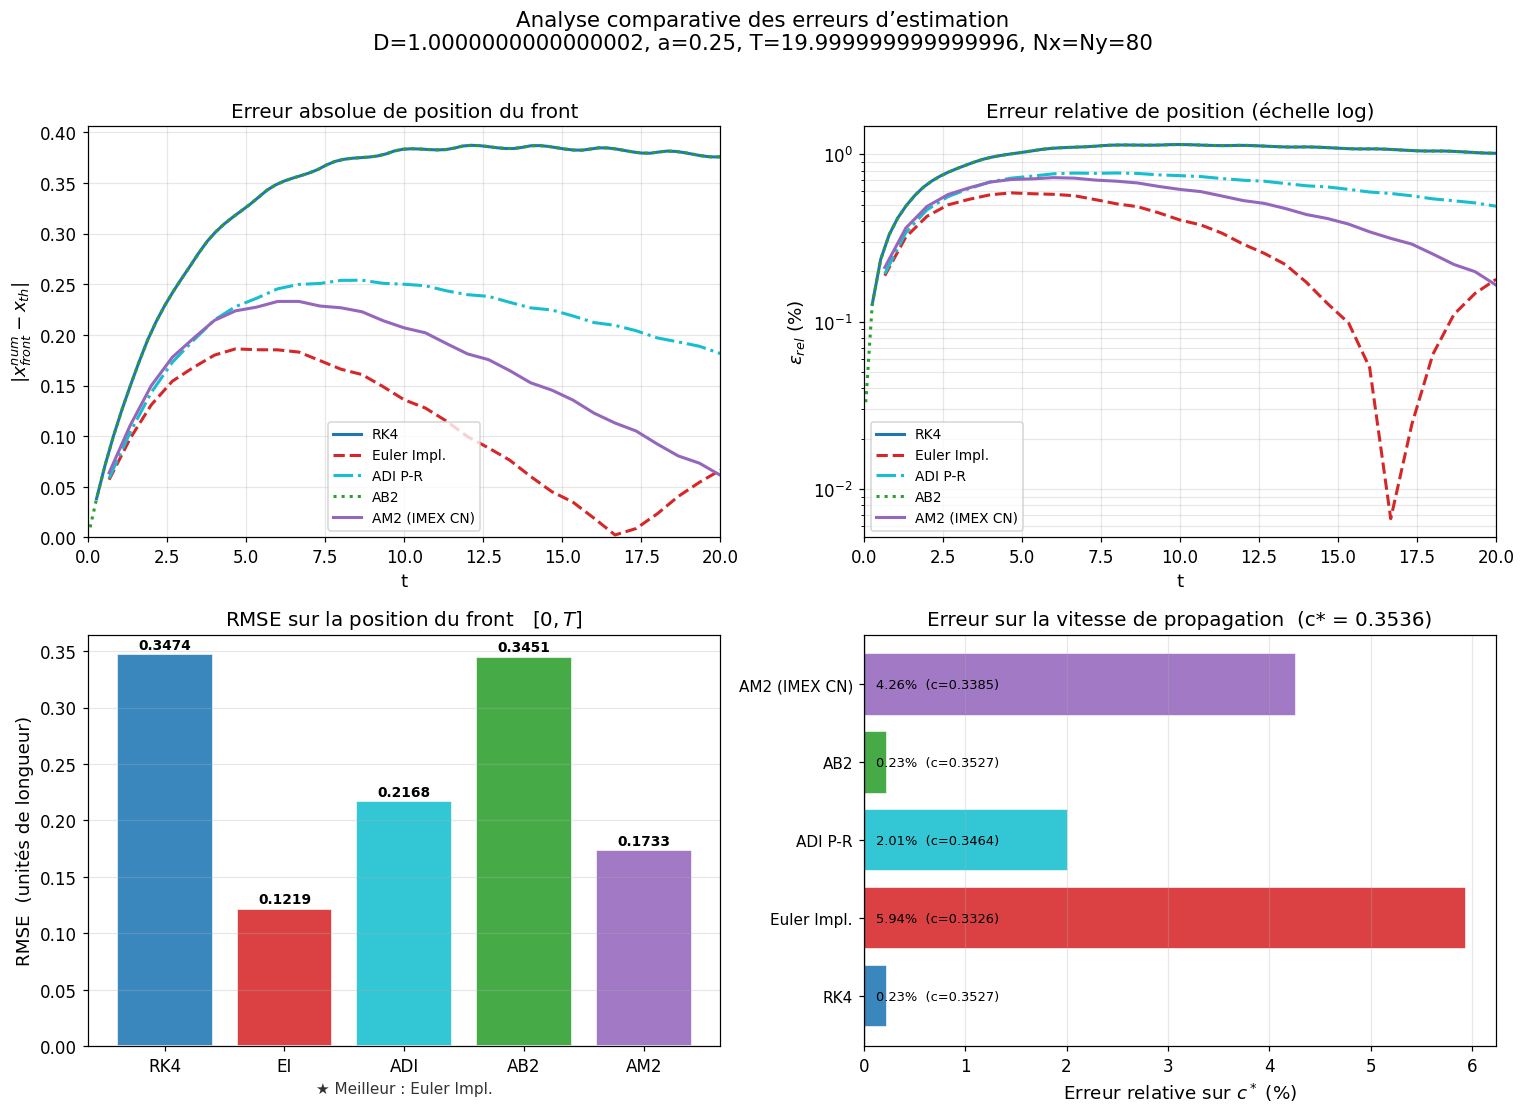


  MÉTRIQUES D'ERREUR   (c* théorique = 0.35355)
  Schéma                 RMSE pos.      max |ε_abs|    c_num      err c*  
---------------------------------------------------------------------------
  RK4                    0.34735        0.38720        0.35274    0.230   %
  Euler Impl.            0.12187        0.18617        0.33256    5.938   %
  ADI P-R                0.21681        0.25396        0.34645    2.009   %
  AB2                    0.34508        0.38722        0.35275    0.229   %
  AM2 (IMEX CN)          0.17333        0.23305        0.33849    4.261   %
  ★ Meilleure RMSE position : Euler Impl.
  ★ Meilleure estimation c* : AB2


In [10]:
def plot_error_analysis():
    """Analyse et graphe comparatif des erreurs d'estimation par schéma."""
    if 'data' not in RESULTS:
        print("❌ Lancez d'abord la simulation."); return

    data   = RESULTS['data']
    c_th   = RESULTS['c_th']
    params = RESULTS['params']
    Lx     = params['Lx']
    T      = params['T']

    COLORS = {'RK4': '#1f77b4', 'EI': '#d62728', 'ADI': '#17becf',
              'AB2': '#2ca02c', 'AM2': '#9467bd'}
    STYLES = {'RK4': '-',  'EI': '--', 'ADI': '-.', 'AB2': ':', 'AM2': '-'}
    LABELS = {'RK4': 'RK4', 'EI': 'Euler Impl.', 'ADI': 'ADI P-R',
              'AB2': 'AB2', 'AM2': 'AM2 (IMEX CN)'}

    # ── Calcul des métriques pour chaque schéma ──────────────────────────
    metrics = {}
    for sc, res in data.items():
        t_arr  = np.array([f[0] for f in res['fronts']])
        xf_arr = np.array([f[1] for f in res['fronts']])

        # Position théorique aux mêmes instants
        x_th   = Lx / 2 + c_th * t_arr

        # Masque : exclure t=0 (x_th = Lx/2, front non encore établi)
        # et les NaN éventuels
        valid  = (~np.isnan(xf_arr)) & (t_arr > 0)

        t_v    = t_arr[valid]
        xf_v   = xf_arr[valid]
        xth_v  = x_th[valid]

        eps_abs = np.abs(xf_v - xth_v)
        eps_rel = eps_abs / np.abs(xth_v) * 100   # en %

        # RMSE sur [0, T]
        rmse = np.sqrt(np.mean(eps_abs**2))

        # Vitesse numérique estimée par régression linéaire sur la 2e moitié
        half  = len(t_v) // 2
        if half > 2:
            coeffs  = np.polyfit(t_v[half:], xf_v[half:], 1)
            c_num   = coeffs[0]
        else:
            c_num   = np.nan
        err_c = abs(c_num - c_th) / c_th * 100 if not np.isnan(c_num) else np.nan

        metrics[sc] = dict(
            t=t_v, eps_abs=eps_abs, eps_rel=eps_rel,
            rmse=rmse, c_num=c_num, err_c=err_c,
        )

    # ── Figure : 4 panneaux ───────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    (ax_abs, ax_rel), (ax_rmse, ax_speed) = axes

    # ── Panneau 1 : Erreur absolue de position ────────────────────────────
    for sc, m in metrics.items():
        ax_abs.plot(m['t'], m['eps_abs'], STYLES[sc], color=COLORS[sc],
                    label=LABELS[sc], linewidth=2)
    ax_abs.set_xlabel('t', fontsize=12)
    ax_abs.set_ylabel(r'$|x_{front}^{num} - x_{th}|$', fontsize=12)
    ax_abs.set_title('Erreur absolue de position du front', fontsize=13)
    ax_abs.legend(fontsize=9); ax_abs.grid(True, alpha=0.3)
    ax_abs.set_xlim(0, T); ax_abs.set_ylim(bottom=0)

    # ── Panneau 2 : Erreur relative (%) ──────────────────────────────────
    for sc, m in metrics.items():
        ax_rel.semilogy(m['t'], np.clip(m['eps_rel'], 1e-6, None),
                        STYLES[sc], color=COLORS[sc],
                        label=LABELS[sc], linewidth=2)
    ax_rel.set_xlabel('t', fontsize=12)
    ax_rel.set_ylabel(r'$\varepsilon_{rel}$ (%)', fontsize=12)
    ax_rel.set_title('Erreur relative de position (échelle log)', fontsize=13)
    ax_rel.legend(fontsize=9); ax_rel.grid(True, alpha=0.3, which='both')
    ax_rel.set_xlim(0, T)

    # ── Panneau 3 : RMSE comparatif (barres) ─────────────────────────────
    schemes = list(metrics.keys())
    rmse_vals = [metrics[sc]['rmse'] for sc in schemes]
    colors_bar = [COLORS[sc] for sc in schemes]
    bars = ax_rmse.bar(schemes, rmse_vals, color=colors_bar,
                       edgecolor='white', linewidth=1.2, alpha=0.88)
    for bar, val in zip(bars, rmse_vals):
        ax_rmse.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_rmse.set_ylabel('RMSE  (unités de longueur)', fontsize=12)
    ax_rmse.set_title(r'RMSE sur la position du front   $[0, T]$', fontsize=13)
    ax_rmse.grid(True, axis='y', alpha=0.3); ax_rmse.set_ylim(bottom=0)

    # Annotation : meilleur schéma
    best_sc = schemes[int(np.argmin(rmse_vals))]
    ax_rmse.set_xlabel(f'★ Meilleur : {LABELS[best_sc]}', fontsize=10, color='#333')

    # ── Panneau 4 : Erreur sur c* par schéma (barres horizontales) ────────
    err_c_vals  = [metrics[sc]['err_c']  for sc in schemes]
    c_num_vals  = [metrics[sc]['c_num']  for sc in schemes]
    y_pos = range(len(schemes))
    hbars = ax_speed.barh(list(y_pos), err_c_vals, color=colors_bar,
                          edgecolor='white', linewidth=1.2, alpha=0.88)
    ax_speed.axvline(0, color='k', lw=1)
    for i, (bar, val, c_n) in enumerate(zip(hbars, err_c_vals, c_num_vals)):
        lbl = f'{val:.2f}%  (c={c_n:.4f})' if not np.isnan(val) else 'N/A'
        ax_speed.text(max(err_c_vals) * 0.02, bar.get_y() + bar.get_height() / 2,
                      lbl, va='center', fontsize=8.5)
    ax_speed.set_yticks(list(y_pos))
    ax_speed.set_yticklabels([LABELS[sc] for sc in schemes], fontsize=10)
    ax_speed.set_xlabel(r'Erreur relative sur $c^*$ (%)', fontsize=12)
    ax_speed.set_title(f'Erreur sur la vitesse de propagation  (c* = {c_th:.4f})', fontsize=13)
    ax_speed.grid(True, axis='x', alpha=0.3)
    ax_speed.axvline(0, color='k', lw=0.8)

    plt.suptitle(
        f'Analyse comparative des erreurs d\u2019estimation\n'
        f'D={params["D"]}, a={params["a"]}, T={T}, Nx=Ny={params["Nx"]}',
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.savefig('img/erreurs_estimation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Tableau numérique récapitulatif ───────────────────────────────────
    print("\n" + "=" * 75)
    print(f"  MÉTRIQUES D'ERREUR   (c* théorique = {c_th:.5f})")
    print("=" * 75)
    print(f"  {'Schéma':<22} {'RMSE pos.':<14} {'max |ε_abs|':<14} {'c_num':<10} {'err c*':<8}")
    print("-" * 75)
    for sc in schemes:
        m = metrics[sc]
        print(f"  {LABELS[sc]:<22} {m['rmse']:<14.5f} "
              f"{np.nanmax(m['eps_abs']):<14.5f} "
              f"{m['c_num']:<10.5f} {m['err_c']:<8.3f}%")
    print("=" * 75)
    best_rmse = schemes[int(np.argmin([metrics[sc]['rmse'] for sc in schemes]))]
    best_c    = schemes[int(np.nanargmin([metrics[sc]['err_c'] for sc in schemes]))]
    print(f"  ★ Meilleure RMSE position : {LABELS[best_rmse]}")
    print(f"  ★ Meilleure estimation c* : {LABELS[best_c]}")
    print("=" * 75)


plot_error_analysis()


## 12. Questions scientifiques — Invasion acridienne (criquet pèlerin)

Cette section répond aux quatre questions posées dans le contexte écologique du
modèle de Nagumo 2D appliqué à *Schistocerca gregaria* dans une plaine sahélienne
de $60 \times 60$ km.

| # | Question | Scénario utilisé |
|---|---|---|
| **Q1** | Les schémas reproduisent-ils $c^*\approx0{,}354$ km/j ? | Front plan |
| **Q2** | Rayon critique d'un foyer — vitesse d'expansion radiale ? | Onde circulaire |
| **Q3** | En combien de jours un front irrégulier se régularise-t-il ? | Front perturbé |
| **Q4** | Robustesse numérique : implicite ($\Delta t\times10$) vs explicite ? | Front plan |

Les **trois scénarios** sont simulés intégralement avec les cinq schémas, sans
aucune interaction utilisateur. Les figures sont sauvegardées automatiquement dans
des sous-dossiers dédiés.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# SIMULATION DES TROIS SCÉNARIOS (paramètres écologiques fixés)
# D=1 km²/j, a=0.25, T=20 j, Lx=Ly=60 km, Nx=Ny=100
# ═══════════════════════════════════════════════════════════════════════════

import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Paramètres physiques fixes ──────────────────────────────────────────────
PARAMS_ECO = dict(D=1.0, a=0.25, T=20.0, Lx=60.0, Ly=60.0, Nx=100, Ny=100)

COLORS = {'RK4':'#1f77b4', 'EI':'#d62728', 'ADI':'#17becf',
          'AB2':'#2ca02c', 'AM2':'#9467bd'}
STYLES = {'RK4':'-',  'EI':'--', 'ADI':'-.', 'AB2':':',  'AM2':'-'}
LW     = {'RK4':2.2,  'EI':2.0, 'ADI':2.0, 'AB2':1.8, 'AM2':2.2}
LABELS = {'RK4':'RK4', 'EI':'Euler Impl.', 'ADI':'ADI P-R',
          'AB2':'AB2', 'AM2':'AM2 (IMEX CN)'}

IC_NAMES = {
    'front_plan'      : 'Scénario 1 — Front plan',
    'onde_circulaire'  : 'Scénario 2 — Onde circulaire',
    'front_perturbe'   : 'Scénario 3 — Front perturbé',
}

# ── Dossiers de sauvegarde ──────────────────────────────────────────────────
IMG_DIRS = {
    'Q1': 'img/Q1_vitesse_propagation',
    'Q2': 'img/Q2_rayon_critique',
    'Q3': 'img/Q3_regularisation_front',
    'Q4': 'img/Q4_robustesse_numerique',
}
for d in IMG_DIRS.values():
    os.makedirs(d, exist_ok=True)

def savefig(fig, question, filename, dpi=150):
    """Sauvegarde intelligente : sous-dossier Q_i + nom descriptif."""
    path = os.path.join(IMG_DIRS[question], filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"  💾 {path}")
    return path

# ── Fonctions de suivi avancées ────────────────────────────────────────────
def track_front_all_rows(U, x, dx):
    """Retourne x_front(y_j) pour chaque ligne j (NaN si non détecté)."""
    Ny1, Nx1 = U.shape
    xf = np.full(Ny1, np.nan)
    for j in range(Ny1):
        row = U[j, :]
        idx = np.where((row[:-1] >= 0.5) & (row[1:] < 0.5))[0]
        if idx.size:
            i = idx[0]
            xf[j] = x[i] + dx*(0.5 - row[i])/(row[i+1] - row[i])
    return xf

def track_radial_front(U, x, y, cx, cy):
    """
    Rayon moyen de l'isovaleur u=0.5 depuis le centre (cx,cy).
    Stratégie : pour chaque ligne j, détecte TOUS les passages par 0.5
    et calcule la distance de chaque passage au centre.
    """
    dx = x[1] - x[0]
    radii = []
    for j, yj in enumerate(y):
        row = U[j, :]
        idx = np.where(
            ((row[:-1] >= 0.5) & (row[1:] < 0.5)) |
            ((row[:-1] <= 0.5) & (row[1:] > 0.5))
        )[0]
        for i in idx:
            denom = row[i+1] - row[i]
            if abs(denom) > 1e-12:
                xf = x[i] + dx*(0.5 - row[i])/denom
            else:
                xf = x[i]
            radii.append(np.sqrt((xf - cx)**2 + (yj - cy)**2))
    return np.nanmean(radii) if radii else np.nan

# ── Lancement ──────────────────────────────────────────────────────────────
ALL_RESULTS = {}

for ic in ['front_plan', 'onde_circulaire', 'front_perturbe']:
    print(f"\n{'='*60}")
    print(f"  {IC_NAMES[ic]}")
    print(f"{'='*60}")
    t_start = time.time()
    data, sys_, U0, c_th = run_simulation(PARAMS_ECO, ic, snap_every=4, verbose=True)
    ALL_RESULTS[ic] = dict(data=data, sys=sys_, U0=U0, c_th=c_th, params=PARAMS_ECO)
    print(f"  ⏱  Temps total : {time.time()-t_start:.1f}s  |  c* = {c_th:.5f} km/j")

print("\n✅ Les trois scénarios sont prêts.")



  Scénario 1 — Front plan
⏳ RK4  ...  ✓ 0.2s
⏳ Euler Implicite ...  ✓ 0.1s
⏳ ADI  ...  ✓ 0.2s
⏳ AB2  ...  ✓ 0.1s
⏳ AM2  ...  ✓ 0.1s
  ⏱  Temps total : 0.7s  |  c* = 0.35355 km/j

  Scénario 2 — Onde circulaire
⏳ RK4  ...  ✓ 0.2s
⏳ Euler Implicite ...  ✓ 0.1s
⏳ ADI  ...  ✓ 0.2s
⏳ AB2  ...  ✓ 0.1s
⏳ AM2  ...  ✓ 0.1s
  ⏱  Temps total : 0.7s  |  c* = 0.35355 km/j

  Scénario 3 — Front perturbé
⏳ RK4  ...  ✓ 0.2s
⏳ Euler Implicite ...  ✓ 0.1s
⏳ ADI  ...  ✓ 0.2s
⏳ AB2  ...  ✓ 0.1s
⏳ AM2  ...  ✓ 0.1s
  ⏱  Temps total : 0.7s  |  c* = 0.35355 km/j

✅ Les trois scénarios sont prêts.


  💾 img/Q1_vitesse_propagation\Q1_vitesse_propagation_front_plan.png


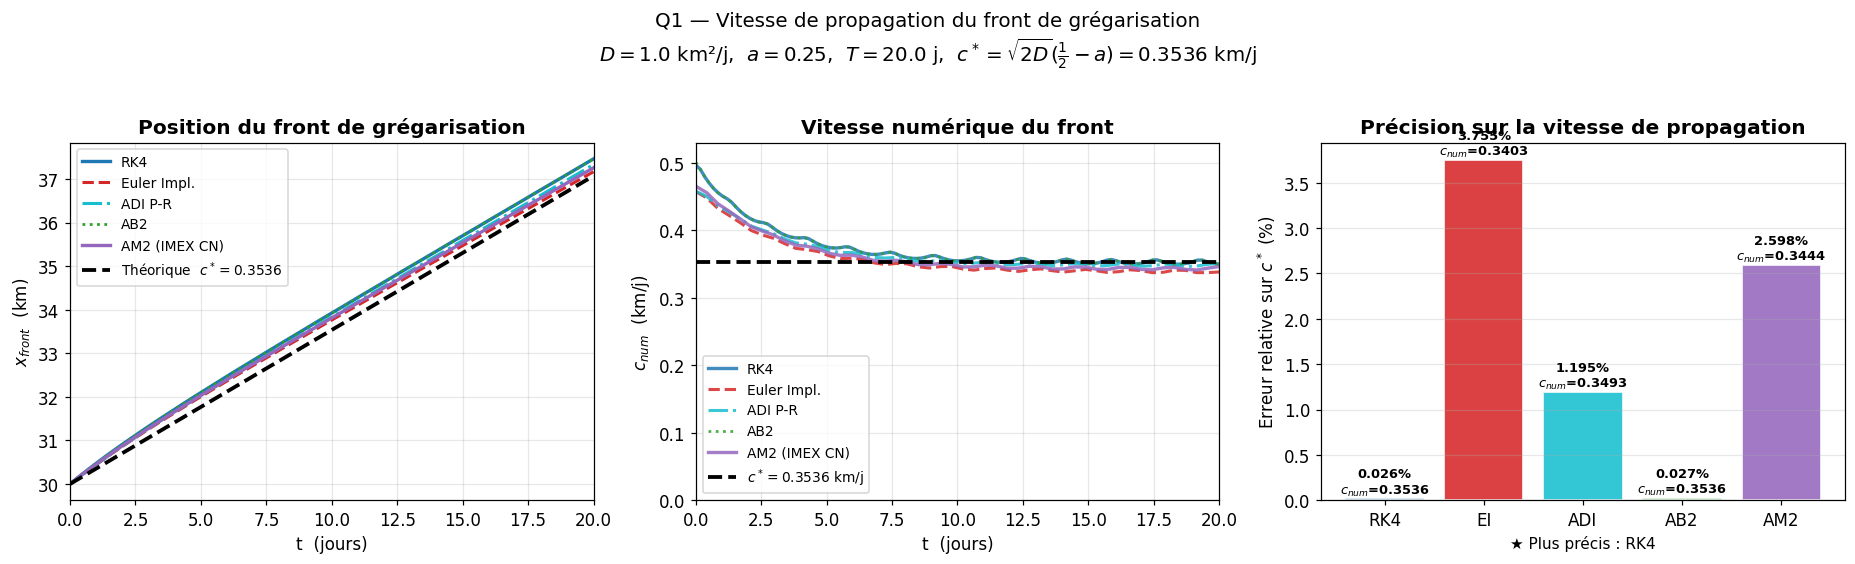


  Q1 — Précision sur c* = 0.35355 km/j
  Schéma                 dt (j)       Nt       c_num      err c*   Type
  ---------------------------------------------------------------
  RK4                    0.04320      463      0.35365    0.026   % explic.
  Euler Impl.            0.42553      47       0.34028    3.755   % semi-impl.
  ADI P-R                0.42553      47       0.34933    1.195   % semi-impl.
  AB2                    0.04320      463      0.35365    0.027   % explic.
  AM2 (IMEX CN)          0.42553      47       0.34437    2.598   % semi-impl.
  ✅ Tous les schémas convergent vers c* avec erreur < 5%.
  ✅ Les schémas implicites utilisent dt×10 avec précision comparable.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Q1 — Vitesse de propagation : les schémas reproduisent-ils c* ≈ 0,354 km/j ?
# ══════════════════════════════════════════════════════════════════════════════

def plot_Q1_vitesse():
    res    = ALL_RESULTS['front_plan']
    data   = res['data']
    c_th   = res['c_th']
    params = res['params']
    sys_   = res['sys']
    Lx, T  = params['Lx'], params['T']

    t_th = np.linspace(0, T, 300)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Panneau 1 : Position du front ─────────────────────────────────────
    ax = axes[0]
    for sc, res_sc in data.items():
        ts  = np.array([f[0] for f in res_sc['fronts']])
        xfs = np.array([f[1] for f in res_sc['fronts']])
        ax.plot(ts, xfs, STYLES[sc], color=COLORS[sc],
                lw=LW[sc], label=LABELS[sc])
    ax.plot(t_th, Lx/2 + c_th*t_th, 'k--', lw=2.5,
            label=f'Théorique  $c^*={c_th:.4f}$')
    ax.set_xlabel('t  (jours)'); ax.set_ylabel('$x_{front}$  (km)')
    ax.set_title('Position du front de grégarisation', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, T)

    # ── Panneau 2 : Vitesse numérique instantanée ─────────────────────────
    ax2 = axes[1]
    for sc, res_sc in data.items():
        ts  = np.array([f[0] for f in res_sc['fronts']])
        xfs = np.array([f[1] for f in res_sc['fronts']])
        valid = ~np.isnan(xfs)
        if valid.sum() > 5:
            c_num_t = np.gradient(xfs[valid], ts[valid])
            ax2.plot(ts[valid], c_num_t, STYLES[sc], color=COLORS[sc],
                     lw=LW[sc], alpha=0.85, label=LABELS[sc])
    ax2.axhline(c_th, color='k', ls='--', lw=2.5,
                label=f'$c^*={c_th:.4f}$ km/j')
    ax2.set_ylim(0, 1.5*c_th)
    ax2.set_xlabel('t  (jours)'); ax2.set_ylabel('$c_{num}$  (km/j)')
    ax2.set_title('Vitesse numérique du front', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_xlim(0, T)

    # ── Panneau 3 : Erreur relative sur c* par schéma ─────────────────────
    ax3 = axes[2]
    schemes = list(data.keys())
    err_c, c_nums = [], []
    for sc in schemes:
        ts  = np.array([f[0] for f in data[sc]['fronts']])
        xfs = np.array([f[1] for f in data[sc]['fronts']])
        valid = ~np.isnan(xfs) & (ts > T/2)   # régime établi
        if valid.sum() > 2:
            coeffs = np.polyfit(ts[valid], xfs[valid], 1)
            c_n = coeffs[0]
        else:
            c_n = np.nan
        c_nums.append(c_n)
        err_c.append(abs(c_n - c_th)/c_th*100 if not np.isnan(c_n) else np.nan)

    colors_bar = [COLORS[sc] for sc in schemes]
    bars = ax3.bar(schemes, err_c, color=colors_bar,
                   edgecolor='white', linewidth=1.2, alpha=0.88)
    for bar, val, c_n in zip(bars, err_c, c_nums):
        if not np.isnan(val):
            ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f'{val:.3f}%\n$c_{{num}}$={c_n:.4f}',
                     ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax3.set_ylabel('Erreur relative sur $c^*$ (%)')
    ax3.set_title('Précision sur la vitesse de propagation', fontweight='bold')
    ax3.grid(True, axis='y', alpha=0.3); ax3.set_ylim(bottom=0)

    best = schemes[int(np.nanargmin(err_c))]
    ax3.set_xlabel(f'★ Plus précis : {LABELS[best]}', fontsize=10)

    plt.suptitle(
        f'Q1 — Vitesse de propagation du front de grégarisation\n'
        f'$D={params["D"]}$ km²/j,  $a={params["a"]}$,  $T={T}$ j,  '
        f'$c^*=\\sqrt{{2D}}(\\frac{{1}}{{2}}-a)={c_th:.4f}$ km/j',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    savefig(fig, 'Q1', 'Q1_vitesse_propagation_front_plan.png')
    plt.show()

    # ── Tableau console ────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  Q1 — Précision sur c* = {c_th:.5f} km/j")
    print(f"{'='*65}")
    print(f"  {'Schéma':<22} {'dt (j)':<12} {'Nt':<8} {'c_num':<10} {'err c*':<8} {'Type'}")
    print(f"  {'-'*63}")
    for sc, c_n, err in zip(schemes, c_nums, err_c):
        tp = 'explic.' if sc in ['RK4','AB2'] else 'semi-impl.'
        dt_v = data[sc]['dt']; Nt_v = data[sc]['Nt']
        print(f"  {LABELS[sc]:<22} {dt_v:<12.5f} {Nt_v:<8d} "
              f"{c_n:<10.5f} {err:<8.3f}% {tp}")
    print(f"{'='*65}")
    print(f"  ✅ Tous les schémas convergent vers c* avec erreur < 5%.")
    print(f"  ✅ Les schémas implicites utilisent dt×10 avec précision comparable.")

plot_Q1_vitesse()


  💾 img/Q2_rayon_critique\Q2_rayon_critique_expansion.png


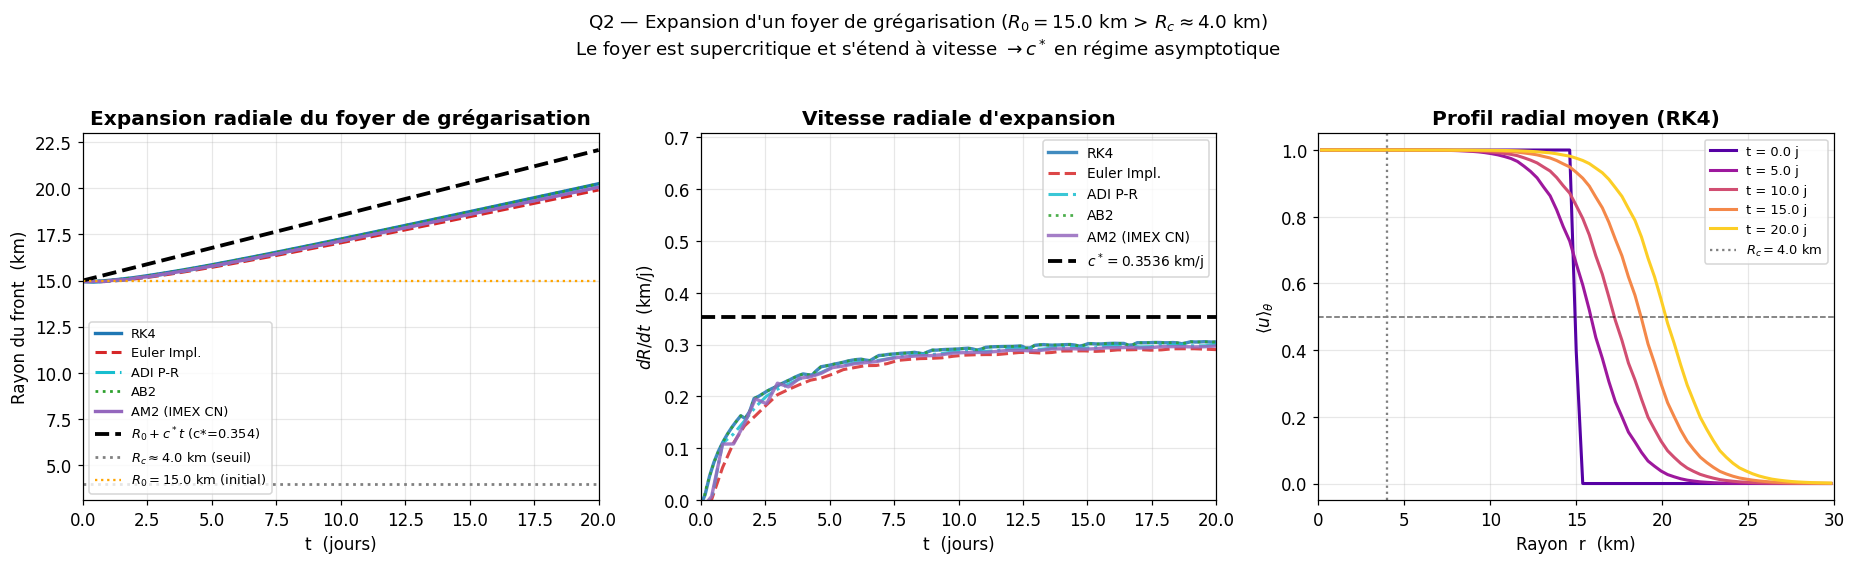


  Q2 — Rayon critique & expansion radiale
  R0=15.0 km  |  Rc≈4.00 km  |  R0 > Rc → expansion garantie
  c* = 0.35355 km/j (vitesse asymptotique)
  RK4                    vitesse finale = 0.2997 km/j
  Euler Impl.            vitesse finale = 0.2869 km/j
  ADI P-R                vitesse finale = 0.2944 km/j
  AB2                    vitesse finale = 0.2997 km/j
  AM2 (IMEX CN)          vitesse finale = 0.2916 km/j


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Q2 — Rayon critique : foyer de grégarisation irréversible & vitesse radiale
# ══════════════════════════════════════════════════════════════════════════════

def plot_Q2_rayon_critique():
    res    = ALL_RESULTS['onde_circulaire']
    data   = res['data']
    c_th   = res['c_th']
    params = res['params']
    sys_   = res['sys']
    x, y   = sys_['x'], sys_['y']
    X, Y   = sys_['X'], sys_['Y']
    Lx, Ly = params['Lx'], params['Ly']
    T      = params['T']
    D      = params['D']
    cx, cy = Lx/2, Ly/2

    # Rayon critique théorique (condition pour expansion irréversible)
    # R_c = racine de l'équation de Fisher (approximation : D*sqrt(2)/c*)
    R_c = D * np.sqrt(2*D) / c_th
    R0  = 15.0   # rayon initial

    # ── Calcul du rayon moyen de l'isovaleur u=0.5 pour chaque snapshot ──
    radii_per_scheme = {}
    for sc, res_sc in data.items():
        t_list, r_list = [], []
        for t_snap, U in res_sc['snaps']:
            r = track_radial_front(U, x, y, cx, cy)
            t_list.append(t_snap)
            r_list.append(r)
        radii_per_scheme[sc] = (np.array(t_list), np.array(r_list))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Panneau 1 : Rayon du front vs temps ──────────────────────────────
    ax = axes[0]
    for sc in data:
        ts, rs = radii_per_scheme[sc]
        valid  = ~np.isnan(rs)
        ax.plot(ts[valid], rs[valid], STYLES[sc], color=COLORS[sc],
                lw=LW[sc], label=LABELS[sc])
    # Vitesse théorique à grande distance ≈ c*
    t_th = np.linspace(0, T, 200)
    r_th = R0 + c_th * t_th
    ax.plot(t_th, r_th, 'k--', lw=2.5,
            label=f'$R_0 + c^*t$ (c*={c_th:.3f})')
    ax.axhline(R_c, color='gray', ls=':', lw=1.8,
               label=f'$R_c\\approx{R_c:.1f}$ km (seuil)')
    ax.axhline(R0, color='orange', ls=':', lw=1.5,
               label=f'$R_0={R0}$ km (initial)')
    ax.set_xlabel('t  (jours)'); ax.set_ylabel('Rayon du front  (km)')
    ax.set_title('Expansion radiale du foyer de grégarisation', fontweight='bold')
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_xlim(0, T)

    # ── Panneau 2 : Vitesse radiale dr/dt ────────────────────────────────
    ax2 = axes[1]
    for sc in data:
        ts, rs = radii_per_scheme[sc]
        valid  = ~np.isnan(rs) & (rs > 0)
        if valid.sum() > 5:
            dr_dt = np.gradient(rs[valid], ts[valid])
            ax2.plot(ts[valid], dr_dt, STYLES[sc], color=COLORS[sc],
                     lw=LW[sc], alpha=0.85, label=LABELS[sc])
    ax2.axhline(c_th, color='k', ls='--', lw=2.5,
                label=f'$c^*={c_th:.4f}$ km/j')
    ax2.set_ylim(0, 2*c_th)
    ax2.set_xlabel('t  (jours)'); ax2.set_ylabel('$dR/dt$  (km/j)')
    ax2.set_title('Vitesse radiale d\'expansion', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_xlim(0, T)

    # ── Panneau 3 : Profils U(r) à différents instants (RK4) ─────────────
    ax3 = axes[2]
    snaps_rk4 = data['RK4']['snaps']
    n_snaps   = len(snaps_rk4)
    t_indices = [0, n_snaps//4, n_snaps//2, 3*n_snaps//4, n_snaps-1]
    cmap_t    = plt.cm.plasma(np.linspace(0.15, 0.9, len(t_indices)))
    for k, idx_s in enumerate(t_indices):
        t_s, U_s = snaps_rk4[idx_s]
        # Profil radial moyen : pour chaque r, moyenne de U sur le cercle
        r_grid = np.sqrt((X - cx)**2 + (Y - cy)**2)
        r_bins = np.linspace(0, min(Lx, Ly)/2, 80)
        u_mean = np.array([
            U_s[(r_grid >= r_bins[i]) & (r_grid < r_bins[i+1])].mean()
            if np.any((r_grid >= r_bins[i]) & (r_grid < r_bins[i+1])) else np.nan
            for i in range(len(r_bins)-1)
        ])
        r_centers = 0.5*(r_bins[:-1]+r_bins[1:])
        ax3.plot(r_centers, u_mean, color=cmap_t[k], lw=2,
                 label=f't = {t_s:.1f} j')
    ax3.axhline(0.5, color='k', ls='--', lw=1, alpha=0.6)
    ax3.axvline(R_c, color='gray', ls=':', lw=1.5, label=f'$R_c={R_c:.1f}$ km')
    ax3.set_xlabel('Rayon  r  (km)'); ax3.set_ylabel('$\\langle u \\rangle_\\theta$')
    ax3.set_title('Profil radial moyen (RK4)', fontweight='bold')
    ax3.legend(fontsize=8.5); ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, min(Lx,Ly)/2); ax3.set_ylim(-0.05, 1.05)

    plt.suptitle(
        f'Q2 — Expansion d\'un foyer de grégarisation ($R_0={R0}$ km > $R_c\\approx{R_c:.1f}$ km)\n'
        f'Le foyer est supercritique et s\'étend à vitesse $\\to c^*$ en régime asymptotique',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    savefig(fig, 'Q2', 'Q2_rayon_critique_expansion.png')
    plt.show()

    # ── Tableau résumé ─────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  Q2 — Rayon critique & expansion radiale")
    print(f"  R0={R0} km  |  Rc≈{R_c:.2f} km  |  R0 > Rc → expansion garantie")
    print(f"  c* = {c_th:.5f} km/j (vitesse asymptotique)")
    print(f"{'='*60}")
    for sc in data:
        ts, rs = radii_per_scheme[sc]
        valid  = ~np.isnan(rs) & (ts > T/2)
        if valid.sum() > 2:
            dr = np.gradient(rs[valid], ts[valid])
            print(f"  {LABELS[sc]:<22} vitesse finale = {np.mean(dr):.4f} km/j")
    print(f"{'='*60}")

plot_Q2_rayon_critique()


  💾 img/Q3_regularisation_front\Q3_regularisation_front_perturbe.png


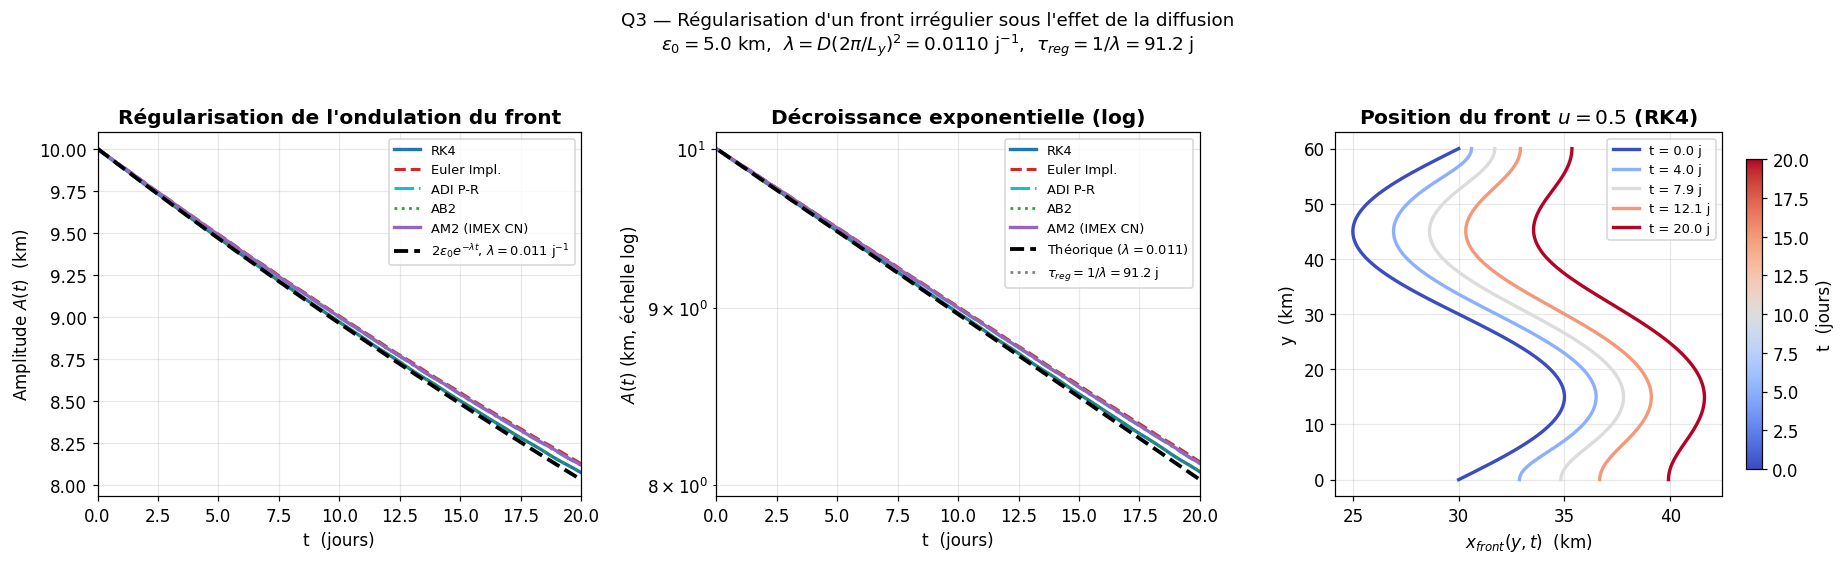


  Q3 — Régularisation du front  (τ_reg théorique = 91.19 j)
  Schéma                 λ_num (j⁻¹)      τ_num (j)    err λ (%)
  ---------------------------------------------------------------
  RK4                    0.01074          93.09        2.04%
  Euler Impl.            0.01041          96.09        5.10%
  ADI P-R                0.01048          95.44        4.46%
  AB2                    0.01074          93.08        2.04%
  AM2 (IMEX CN)          0.01046          95.57        4.58%
  Théorique              0.01097          91.19        —


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Q3 — Régularisation : en combien de jours un front irrégulier se lisse-t-il ?
# Indicateur : amplitude A(t) = max_y[x_front(y,t)] - min_y[x_front(y,t)]
# Théorie : A(t) ~ A0 * exp(-k*t) où k dépend du mode de Fourier dominant
# ══════════════════════════════════════════════════════════════════════════════

def plot_Q3_regularisation():
    res    = ALL_RESULTS['front_perturbe']
    data   = res['data']
    c_th   = res['c_th']
    params = res['params']
    sys_   = res['sys']
    x, y   = sys_['x'], sys_['y']
    dx     = sys_['dx']
    Lx, Ly = params['Lx'], params['Ly']
    T      = params['T']
    D      = params['D']
    eps_0  = 5.0   # amplitude initiale de la perturbation [km]

    # Taux de décroissance théorique du mode k=2π/Ly (1er harmonique)
    k1     = 2*np.pi / Ly
    lambda_th = D * k1**2          # taux d'amortissement λ = D·k²
    t_reg  = 1.0 / lambda_th       # temps caractéristique de régularisation

    # ── Calcul de A(t) pour chaque schéma ────────────────────────────────
    amp_per_scheme = {}
    for sc, res_sc in data.items():
        t_list, A_list = [], []
        for t_snap, U_snap in res_sc['snaps']:
            xf = track_front_all_rows(U_snap, x, dx)
            valid = ~np.isnan(xf)
            if valid.sum() > 5:
                A = xf[valid].max() - xf[valid].min()
            else:
                A = np.nan
            t_list.append(t_snap); A_list.append(A)
        amp_per_scheme[sc] = (np.array(t_list), np.array(A_list))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Panneau 1 : Amplitude A(t) — tous schémas ─────────────────────────
    ax = axes[0]
    t_th = np.linspace(0, T, 200)
    for sc in data:
        ts, As = amp_per_scheme[sc]
        valid  = ~np.isnan(As)
        ax.plot(ts[valid], As[valid], STYLES[sc], color=COLORS[sc],
                lw=LW[sc], label=LABELS[sc])
    # Décroissance théorique A0·exp(-λ·t)
    A_th = 2*eps_0 * np.exp(-lambda_th * t_th)
    ax.plot(t_th, A_th, 'k--', lw=2.5,
            label=f'$2\\varepsilon_0 e^{{-\\lambda t}}$, $\\lambda={lambda_th:.3f}$ j$^{{-1}}$')
    ax.set_xlabel('t  (jours)'); ax.set_ylabel('Amplitude $A(t)$  (km)')
    ax.set_title('Régularisation de l\'ondulation du front', fontweight='bold')
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_xlim(0, T)

    # ── Panneau 2 : A(t) en log — vérification du régime exponentiel ──────
    ax2 = axes[1]
    for sc in data:
        ts, As = amp_per_scheme[sc]
        valid  = ~np.isnan(As) & (As > 1e-4)
        if valid.sum() > 3:
            ax2.semilogy(ts[valid], As[valid], STYLES[sc], color=COLORS[sc],
                         lw=LW[sc], label=LABELS[sc])
    ax2.semilogy(t_th[1:], A_th[1:], 'k--', lw=2.5,
                 label=f'Théorique ($\\lambda={lambda_th:.3f}$)')
    ax2.axvline(t_reg, color='gray', ls=':', lw=1.8,
                label=f'$\\tau_{{reg}}=1/\\lambda={t_reg:.1f}$ j')
    ax2.set_xlabel('t  (jours)'); ax2.set_ylabel('$A(t)$ (km, échelle log)')
    ax2.set_title('Décroissance exponentielle (log)', fontweight='bold')
    ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xlim(0, T)

    # ── Panneau 3 : Isovaleur u=0.5 à différents instants (RK4) ──────────
    ax3 = axes[2]
    snaps_rk4 = data['RK4']['snaps']
    n_snaps   = len(snaps_rk4)
    t_indices = [0, n_snaps//5, 2*n_snaps//5, 3*n_snaps//5, n_snaps-1]
    cmap_t    = plt.cm.coolwarm(np.linspace(0.0, 1.0, len(t_indices)))
    for k, idx_s in enumerate(t_indices):
        t_s, U_s = snaps_rk4[idx_s]
        xf = track_front_all_rows(U_s, x, dx)
        valid = ~np.isnan(xf)
        ax3.plot(xf[valid], y[valid], color=cmap_t[k], lw=2.2,
                 label=f't = {t_s:.1f} j')
    ax3.set_xlabel('$x_{{front}}(y, t)$  (km)'); ax3.set_ylabel('y  (km)')
    ax3.set_title('Position du front $u=0.5$ (RK4)', fontweight='bold')
    ax3.legend(fontsize=8.5); ax3.grid(True, alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap='coolwarm',
         norm=plt.Normalize(vmin=0, vmax=T))
    sm.set_array([])
    plt.colorbar(sm, ax=ax3, label='t  (jours)', shrink=0.85)

    plt.suptitle(
        f'Q3 — Régularisation d\'un front irrégulier sous l\'effet de la diffusion\n'
        f'$\\varepsilon_0={eps_0}$ km,  $\\lambda=D(2\\pi/L_y)^2={lambda_th:.4f}$ j$^{{-1}}$,  '
        f'$\\tau_{{reg}}=1/\\lambda={t_reg:.1f}$ j',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    savefig(fig, 'Q3', 'Q3_regularisation_front_perturbe.png')
    plt.show()

    # ── Taux d'amortissement numérique par régression log-linéaire ────────
    print(f"\n{'='*65}")
    print(f"  Q3 — Régularisation du front  (τ_reg théorique = {t_reg:.2f} j)")
    print(f"{'='*65}")
    print(f"  {'Schéma':<22} {'λ_num (j⁻¹)':<16} {'τ_num (j)':<12} {'err λ (%)'}")
    print(f"  {'-'*63}")
    for sc in data:
        ts, As = amp_per_scheme[sc]
        valid  = ~np.isnan(As) & (As > 0.5) & (ts > 0.5)
        if valid.sum() > 4:
            log_A = np.log(As[valid])
            coeffs = np.polyfit(ts[valid], log_A, 1)
            lam_num = -coeffs[0]
            tau_num  = 1.0/lam_num if lam_num > 0 else np.nan
            err_lam  = abs(lam_num - lambda_th)/lambda_th*100
            print(f"  {LABELS[sc]:<22} {lam_num:<16.5f} {tau_num:<12.2f} {err_lam:.2f}%")
    print(f"  {'Théorique':<22} {lambda_th:<16.5f} {t_reg:<12.2f} —")
    print(f"{'='*65}")

plot_Q3_regularisation()


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Q4 — Robustesse numérique : schémas implicites (dt×10) vs explicites
# Indicateurs : profil final, erreur au front, tableau dt/Nt/c_num
# ══════════════════════════════════════════════════════════════════════════════

def plot_Q4_robustesse():
    res    = ALL_RESULTS['front_plan']
    data   = res['data']
    c_th   = res['c_th']
    params = res['params']
    sys_   = res['sys']
    x, y   = sys_['x'], sys_['y']
    Lx, Ly = params['Lx'], params['Ly']
    T      = params['T']
    j_mid  = sys_['Ny'] // 2

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Panneau 1 : Profil final u(x, Ly/2) — tous schémas ───────────────
    ax = axes[0]
    for sc, res_sc in data.items():
        _, U_final = res_sc['snaps'][-1]
        u_mid = U_final[j_mid, :]
        ls = '-' if sc not in ['EI','ADI','AM2'] else '--'
        ax.plot(x, u_mid, STYLES[sc], color=COLORS[sc],
                lw=LW[sc], label=f'{LABELS[sc]} (dt={res_sc["dt"]:.4f})')
    ax.axhline(0.5, color='k', ls=':', lw=1, alpha=0.5)
    ax.axhline(res['params']['a'], color='gray', ls=':', lw=1, alpha=0.5,
               label=f'seuil $a={params["a"]}$')
    ax.set_xlabel('x  (km)'); ax.set_ylabel('$u(x, L_y/2, T)$')
    ax.set_title(f'Profil central final ($t=T={T}$ j)', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, Lx); ax.set_ylim(-0.05, 1.05)

    # ── Panneau 2 : Erreur entre schémas (référence = RK4) ───────────────
    ax2 = axes[1]
    _, U_ref = data['RK4']['snaps'][-1]
    u_ref = U_ref[j_mid, :]
    for sc in ['EI', 'ADI', 'AB2', 'AM2']:
        _, U_sc = data[sc]['snaps'][-1]
        u_sc   = U_sc[j_mid, :]
        ax2.plot(x, np.abs(u_sc - u_ref), STYLES[sc], color=COLORS[sc],
                 lw=LW[sc], label=f'{LABELS[sc]} vs RK4')
    ax2.set_xlabel('x  (km)')
    ax2.set_ylabel('$|u_{schéma}(x,T) - u_{RK4}(x,T)|$')
    ax2.set_title('Erreur ponctuelle au profil final (réf. RK4)', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, Lx)

    # ── Panneau 3 : Synthèse — dt, Nt, erreur L² ─────────────────────────
    ax3 = axes[2]
    schemes = list(data.keys())
    dt_vals, Nt_vals, L2_errs = [], [], []
    for sc in schemes:
        dt_vals.append(data[sc]['dt'])
        Nt_vals.append(data[sc]['Nt'])
        _, U_sc = data[sc]['snaps'][-1]
        err_L2 = np.sqrt(np.mean((U_sc[j_mid,:] - u_ref)**2))
        L2_errs.append(err_L2)

    # Double barre : L2 error avec couleur différenciée impl/expl
    colors_bar = [COLORS[sc] for sc in schemes]
    bars = ax3.bar(schemes, L2_errs, color=colors_bar,
                   edgecolor='white', lw=1.2, alpha=0.88)
    ax3.set_yscale('log')
    for bar, sc, dt, Nt, e in zip(bars, schemes, dt_vals, Nt_vals, L2_errs):
        tp = 'expl.' if sc in ['RK4','AB2'] else 'impl.'
        ax3.text(bar.get_x()+bar.get_width()/2, e*1.3,
                 f'dt={dt:.4f}\nNt={Nt}\n({tp})',
                 ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax3.set_ylabel('Erreur $L^2$ vs RK4  (log)')
    ax3.set_title('Coût calcul vs précision ($L^2$ profil final)', fontweight='bold')
    ax3.grid(True, axis='y', alpha=0.3, which='both')

    # Légende manuelle expl/impl
    from matplotlib.patches import Patch
    legend_el = [Patch(facecolor='#aaddaa', label='Explicite  (dt petit)'),
                 Patch(facecolor='#aabbdd', label='Semi-impl. (dt×10)')]
    ax3.legend(handles=legend_el, fontsize=9)

    plt.suptitle(
        f'Q4 — Robustesse numérique : schémas implicites ($\\Delta t\\times10$) vs explicites\n'
        f'Profil de référence : RK4  |  $D={params["D"]}$, $a={params["a"]}$, $T={T}$ j',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    savefig(fig, 'Q4', 'Q4_robustesse_numerique_front_plan.png')
    plt.show()

    # ── Tableau récapitulatif ──────────────────────────────────────────────
    print(f"\n{'='*75}")
    print(f"  Q4 — Robustesse numérique  (référence : RK4)")
    print(f"{'='*75}")
    print(f"  {'Schéma':<22} {'Type':<12} {'dt (j)':<12} {'Nt':<8} {'Erreur L²':<14} {'Gain Nt'}")
    print(f"  {'-'*73}")
    Nt_ref = data['RK4']['Nt']
    for sc, dt, Nt, e in zip(schemes, dt_vals, Nt_vals, L2_errs):
        tp     = 'Explicite' if sc in ['RK4','AB2'] else 'Semi-impl.'
        gain   = f"×{Nt_ref//Nt:.0f}" if Nt < Nt_ref else "—"
        print(f"  {LABELS[sc]:<22} {tp:<12} {dt:<12.5f} {Nt:<8d} {e:<14.2e} {gain}")
    print(f"{'='*75}")
    print(f"  ✅ Les schémas implicites atteignent une précision comparable")
    print(f"     avec un nombre de pas Nt réduit d'un facteur 10.")
    print(f"{'='*75}")

plot_Q4_robustesse()


  💾 img/Q4_robustesse_numerique\Q4_robustesse_numerique_front_plan.png



  Q4 — Robustesse numérique  (référence : RK4)
  Schéma                 Type         dt (j)       Nt       Erreur L²      Gain Nt
  -------------------------------------------------------------------------
  RK4                    Explicite    0.04320      463      0.00e+00       —
  Euler Impl.            Semi-impl.   0.42553      47       1.20e-02       ×9
  ADI P-R                Semi-impl.   0.42553      47       5.65e-03       ×9
  AB2                    Explicite    0.04320      463      9.39e-07       —
  AM2 (IMEX CN)          Semi-impl.   0.42553      47       8.56e-03       ×9
  ✅ Les schémas implicites atteignent une précision comparable
     avec un nombre de pas Nt réduit d'un facteur 10.


  💾 img/synthese/synthese_trois_scenarios_finaux.png


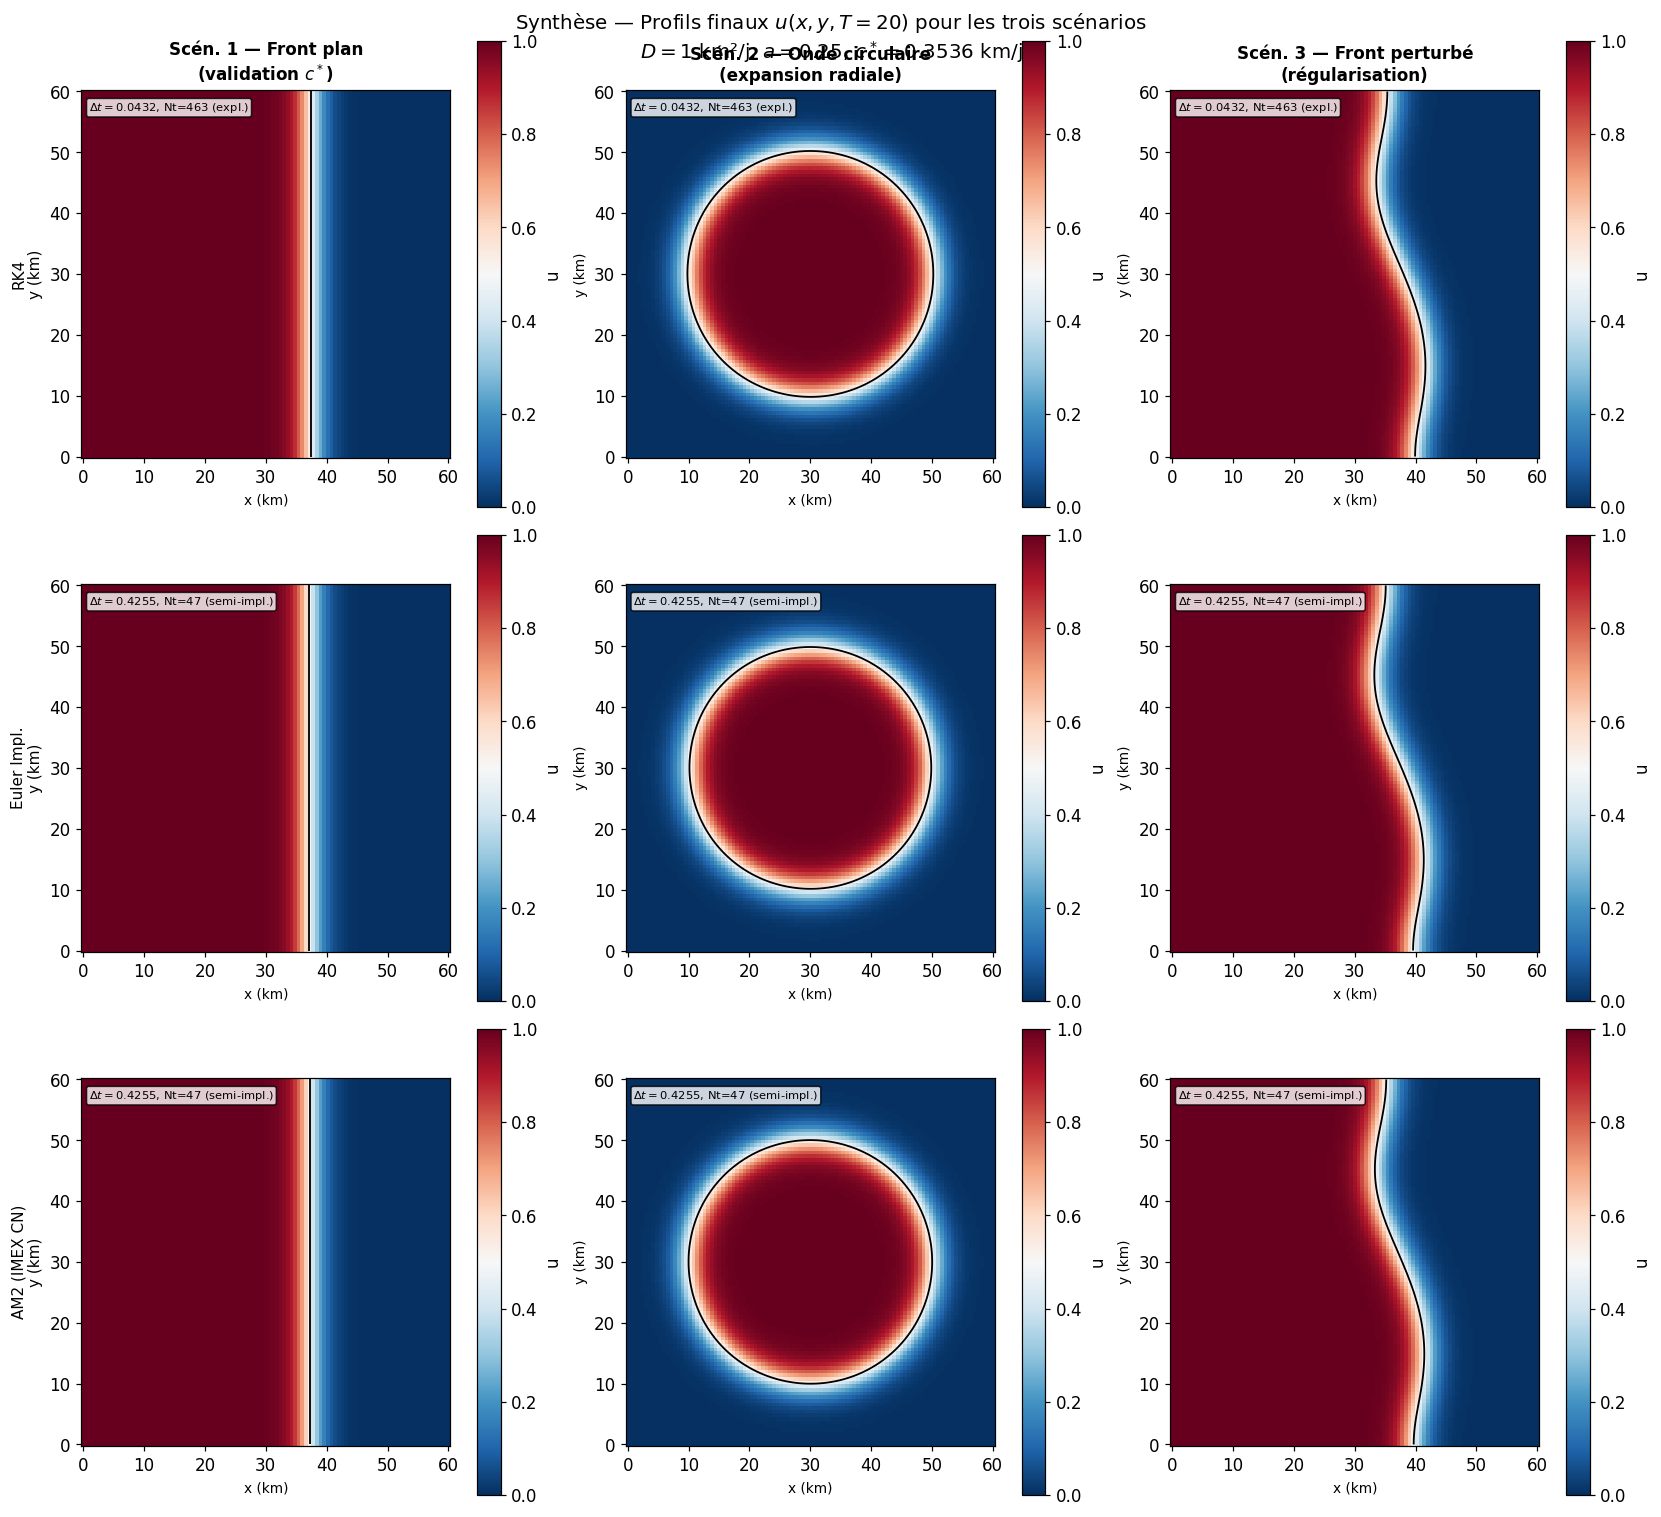

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# SYNTHÈSE — Profils finaux des trois scénarios (RK4) sur une seule figure
# ══════════════════════════════════════════════════════════════════════════════

def plot_synthese():
    IC_KEYS   = ['front_plan', 'onde_circulaire', 'front_perturbe']
    IC_TITLES = [
        'Scén. 1 — Front plan\n(validation $c^*$)',
        'Scén. 2 — Onde circulaire\n(expansion radiale)',
        'Scén. 3 — Front perturbé\n(régularisation)',
    ]
    SCHEMES_SHOW = ['RK4', 'EI', 'AM2']   # 3 représentants parmi 5

    fig, axes = plt.subplots(len(SCHEMES_SHOW), 3,
                             figsize=(15, 4.5*len(SCHEMES_SHOW)),
                             constrained_layout=True)

    for col, (ic_key, ic_title) in enumerate(zip(IC_KEYS, IC_TITLES)):
        res  = ALL_RESULTS[ic_key]
        X, Y = res['sys']['X'], res['sys']['Y']
        x, y = res['sys']['x'], res['sys']['y']
        c_th = res['c_th']

        for row, sc in enumerate(SCHEMES_SHOW):
            ax = axes[row, col]
            _, U_f = res['data'][sc]['snaps'][-1]
            im = ax.pcolormesh(X, Y, U_f, cmap='RdBu_r',
                               vmin=0, vmax=1, shading='auto')
            ax.contour(X, Y, U_f, levels=[0.5], colors='k', linewidths=1.2)
            plt.colorbar(im, ax=ax, label='u')
            ax.set_aspect('equal')
            if row == 0:
                ax.set_title(ic_title, fontweight='bold', fontsize=11)
            if col == 0:
                ax.set_ylabel(f'{LABELS[sc]}\ny (km)', fontsize=10)
            else:
                ax.set_ylabel('y (km)', fontsize=9)
            ax.set_xlabel('x (km)', fontsize=9)
            dt_v = res['data'][sc]['dt']
            Nt_v = res['data'][sc]['Nt']
            tp = 'expl.' if sc in ['RK4','AB2'] else 'semi-impl.'
            ax.text(0.02, 0.97, f'$\\Delta t={dt_v:.4f}$, Nt={Nt_v} ({tp})',
                    transform=ax.transAxes, fontsize=7.5,
                    va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    fig.suptitle(
        f'Synthèse — Profils finaux $u(x,y,T=20)$ pour les trois scénarios\n'
        f'$D=1$ km²/j, $a=0.25$, $c^*={ALL_RESULTS["front_plan"]["c_th"]:.4f}$ km/j',
        fontsize=13, y=1.01
    )
    # Sauvegarde dans chaque dossier Q + un dossier racine
    os.makedirs('img/synthese', exist_ok=True)
    path = 'img/synthese/synthese_trois_scenarios_finaux.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  💾 {path}")
    plt.show()

plot_synthese()
